In [1]:
# ============================================================================
# CELL 1: Install Dependencies & Setup
# ============================================================================

# Install required libraries
!pip install -q sentencepiece sacrebleu rouge-score matplotlib seaborn tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import unicodedata
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.1 MB/s eta 0:00:00
Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


In [2]:
# ============================================================================
# CELL 2: Load and Inspect Dataset
# ============================================================================

from google.colab import files
import pandas as pd

print("Please upload your 'final_main_dataset.tsv' file:")
uploaded = files.upload()

# Load the dataset with proper column names
# Columns: client_id, path, sentence, up_votes, down_votes, age, gender, accents, variant, locale, segment
df = pd.read_csv('final_main_dataset.tsv', sep='\t', encoding='utf-8')

# Display column names
print(f"Dataset loaded successfully!")
print(f"Columns: {df.columns.tolist()}")
print(f"Total rows: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())

# Extract sentences from the 'sentence' column
sentences = df['sentence'].dropna().tolist()
print(f"\nTotal valid sentences: {len(sentences)}")

# Basic statistics
sentence_lengths = [len(sent.split()) for sent in sentences]
print(f"\nDataset Statistics:")
print(f"  - Min sentence length: {min(sentence_lengths)} words")
print(f"  - Max sentence length: {max(sentence_lengths)} words")
print(f"  - Average sentence length: {np.mean(sentence_lengths):.2f} words")
print(f"  - Median sentence length: {np.median(sentence_lengths):.2f} words")

print(f"\nSample sentences:")
for i, sent in enumerate(sentences[:5], 1):
    print(f"{i}. {sent}")

# Optional: Display additional metadata statistics
print(f"\n=== Additional Metadata Statistics ===")
if 'gender' in df.columns:
    print(f"\nGender distribution:")
    print(df['gender'].value_counts())
if 'age' in df.columns:
    print(f"\nAge distribution:")
    print(df['age'].value_counts())
if 'locale' in df.columns:
    print(f"\nLocale distribution:")
    print(df['locale'].value_counts())
if 'variant' in df.columns:
    print(f"\nVariant distribution:")
    print(df['variant'].value_counts())

Please upload your 'final_main_dataset.tsv' file:


Saving final_main_dataset.tsv to final_main_dataset.tsv
Dataset loaded successfully!
Columns: ['client_id', 'path', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']
Total rows: 20000

First 5 rows:
                                           client_id  \
0  e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...   
1  e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...   
2  e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...   
3  e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...   
4  e53f84d151d6cc6d45a57decde08a99efe47d7751a4ca6...   

                           path  \
0  common_voice_ur_31771683.mp3   
1  common_voice_ur_31771684.mp3   
2  common_voice_ur_31771685.mp3   
3  common_voice_ur_31771730.mp3   
4  common_voice_ur_31771732.mp3   

                                            sentence  up_votes  down_votes  \
0                 کبھی کبھار ہی خیالی پلاو بناتا ہوں         2           0   
1                  اور پھر ممکن ہے کہ پاکستان بھی

In [3]:
# ============================================================================
# CELL 3: Urdu Text Preprocessing
# ============================================================================

def normalize_urdu_text(text: str) -> str:
    """
    Normalize Urdu text by:
    - Removing extra whitespaces
    - Normalizing Unicode characters
    - Removing control characters
    - Preserving Urdu script and punctuation
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Normalize Unicode (NFKC normalization)
    text = unicodedata.normalize('NFKC', text)

    # Remove control characters but keep newlines and tabs
    text = ''.join(char for char in text if unicodedata.category(char)[0] != 'C' or char in '\n\t')

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text

def urdu_tokenizer(text: str) -> List[str]:
    """
    Simple word-level tokenizer for Urdu text.
    Splits on whitespace and keeps punctuation attached.
    """
    text = normalize_urdu_text(text)
    # Simple whitespace tokenization
    tokens = text.split()
    return tokens

# Preprocess all sentences
print("Preprocessing Urdu text...")
preprocessed_sentences = []
for sent in tqdm(sentences, desc="Normalizing"):
    normalized = normalize_urdu_text(sent)
    if normalized and len(normalized.split()) >= 3:  # Keep sentences with at least 3 words
        preprocessed_sentences.append(normalized)

print(f"\nPreprocessed {len(preprocessed_sentences)} sentences")
print(f"Removed {len(sentences) - len(preprocessed_sentences)} invalid/short sentences")
print(f"\nExample preprocessed sentences:")
for i, sent in enumerate(preprocessed_sentences[:5], 1):
    print(f"{i}. {sent}")

Preprocessing Urdu text...


Normalizing: 100%|██████████| 20000/20000 [00:00<00:00, 81209.57it/s]


Preprocessed 19393 sentences
Removed 607 invalid/short sentences

Example preprocessed sentences:
1. کبھی کبھار ہی خیالی پلاو بناتا ہوں
2. اور پھر ممکن ہے کہ پاکستان بھی ہو
3. یہ فیصلہ بھی گزشتہ دو سال میں
4. ان کے بلے بازوں کے سامنے ہو گا
5. آبی جانور میں بطخ بگلا اور دُوسْرا آبی پرندہ شامل ہونا


In [4]:
# ============================================================================
# CELL 4: Build Vocabulary
# ============================================================================

class Vocabulary:
    def __init__(self, max_vocab_size=None, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()

        # Special tokens
        self.PAD_TOKEN = '<PAD>'
        self.UNK_TOKEN = '<UNK>'
        self.BOS_TOKEN = '<BOS>'
        self.EOS_TOKEN = '<EOS>'
        self.MASK_TOKEN = '<MASK>'

        self.special_tokens = [
            self.PAD_TOKEN,
            self.UNK_TOKEN,
            self.BOS_TOKEN,
            self.EOS_TOKEN,
            self.MASK_TOKEN
        ]

        # Initialize special tokens
        for token in self.special_tokens:
            self.add_word(token)

    def add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def build_vocab(self, tokenized_sentences):
        """Build vocabulary from tokenized sentences."""
        # Count word frequencies
        for tokens in tqdm(tokenized_sentences, desc="Counting words"):
            self.word_freq.update(tokens)

        # Filter by frequency and limit vocabulary size
        valid_words = [
            word for word, freq in self.word_freq.items()
            if freq >= self.min_freq and word not in self.special_tokens
        ]

        # Sort by frequency (most common first)
        valid_words = sorted(valid_words, key=lambda w: self.word_freq[w], reverse=True)

        # Limit vocabulary size
        if self.max_vocab_size:
            valid_words = valid_words[:self.max_vocab_size - len(self.special_tokens)]

        # Add words to vocabulary
        for word in valid_words:
            self.add_word(word)

    def encode(self, tokens):
        """Convert tokens to indices."""
        return [self.word2idx.get(token, self.word2idx[self.UNK_TOKEN]) for token in tokens]

    def decode(self, indices):
        """Convert indices to tokens."""
        return [self.idx2word.get(idx, self.UNK_TOKEN) for idx in indices]

    def __len__(self):
        return len(self.word2idx)

# Tokenize all sentences
print("Tokenizing sentences...")
tokenized_sentences = [urdu_tokenizer(sent) for sent in tqdm(preprocessed_sentences, desc="Tokenizing")]

# Build vocabulary
print("\nBuilding vocabulary...")
vocab = Vocabulary(max_vocab_size=20000, min_freq=2)
vocab.build_vocab(tokenized_sentences)

print(f"\nVocabulary Statistics:")
print(f"  - Vocabulary size: {len(vocab)}")
print(f"  - PAD token index: {vocab.word2idx[vocab.PAD_TOKEN]}")
print(f"  - UNK token index: {vocab.word2idx[vocab.UNK_TOKEN]}")
print(f"  - BOS token index: {vocab.word2idx[vocab.BOS_TOKEN]}")
print(f"  - EOS token index: {vocab.word2idx[vocab.EOS_TOKEN]}")
print(f"  - MASK token index: {vocab.word2idx[vocab.MASK_TOKEN]}")
print(f"\nMost common words (excluding special tokens):")
common_words = [(w, f) for w, f in vocab.word_freq.most_common(15) if w not in vocab.special_tokens]
for word, freq in common_words[:10]:
    print(f"  {word}: {freq}")

Tokenizing sentences...


Tokenizing: 100%|██████████| 19393/19393 [00:00<00:00, 66932.35it/s]



Building vocabulary...


Counting words: 100%|██████████| 19393/19393 [00:00<00:00, 489037.48it/s]


Vocabulary Statistics:
  - Vocabulary size: 8477
  - PAD token index: 0
  - UNK token index: 1
  - BOS token index: 2
  - EOS token index: 3
  - MASK token index: 4

Most common words (excluding special tokens):
  کی: 4244
  کے: 4170
  میں: 4151
  کا: 3223
  سے: 2785
  ہے: 2778
  ہے۔: 2656
  کو: 2065
  اور: 1894
  اس: 1843


In [5]:
# ============================================================================
# CELL 5: Copy-Reconstruction Dataset (IMPROVED APPROACH)
# ============================================================================

class CopyReconstructionDataset(Dataset):
    """
    Copy-Reconstruction task: Input with noise -> Clean output
    This works much better than span corruption for single-sentence datasets.
    """
    def __init__(self, tokenized_sentences, vocab, max_length=64, noise_prob=0.20):
        self.tokenized_sentences = tokenized_sentences
        self.vocab = vocab
        self.max_length = max_length
        self.noise_prob = noise_prob

        self.valid_sentences = [
            sent for sent in tokenized_sentences
            if 3 <= len(sent) <= max_length - 2
        ]

        print(f"Valid sentences: {len(self.valid_sentences)}/{len(tokenized_sentences)}")

    def add_noise(self, tokens):
        """Add noise by randomly masking, replacing, or deleting tokens."""
        noisy_tokens = []

        for token in tokens:
            rand = random.random()

            if rand < self.noise_prob:
                # 60% mask, 20% replace with random, 20% delete
                noise_type = random.random()
                if noise_type < 0.6:
                    noisy_tokens.append(self.vocab.MASK_TOKEN)  # Mask
                elif noise_type < 0.8:
                    # Replace with random vocab word (avoid special tokens)
                    random_idx = random.randint(5, len(self.vocab) - 1)
                    random_word = self.vocab.idx2word[random_idx]
                    noisy_tokens.append(random_word)
                # else: delete (don't append)
            else:
                noisy_tokens.append(token)

        # Ensure we have at least some tokens
        if not noisy_tokens:
            noisy_tokens = [self.vocab.MASK_TOKEN]

        return noisy_tokens

    def __getitem__(self, idx):
        tokens = self.valid_sentences[idx].copy()

        # Create noisy input
        noisy_tokens = self.add_noise(tokens)

        # Clean output
        clean_tokens = tokens

        # Add special tokens
        input_tokens = [self.vocab.BOS_TOKEN] + noisy_tokens + [self.vocab.EOS_TOKEN]
        target_tokens = [self.vocab.BOS_TOKEN] + clean_tokens + [self.vocab.EOS_TOKEN]

        # Encode
        input_ids = self.vocab.encode(input_tokens)
        target_ids = self.vocab.encode(target_tokens)

        # Pad
        input_ids = input_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(input_ids))
        target_ids = target_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(target_ids))

        # Truncate
        input_ids = input_ids[:self.max_length]
        target_ids = target_ids[:self.max_length]

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
        }

    def __len__(self):
        return len(self.valid_sentences)

# Test the dataset
print("\n" + "="*70)
print("Testing Copy-Reconstruction Dataset")
print("="*70)

test_dataset = CopyReconstructionDataset(tokenized_sentences[:10], vocab, max_length=64)
sample = test_dataset[0]

print(f"\nSample from dataset:")
input_decoded = vocab.decode(sample['input_ids'].tolist())
target_decoded = vocab.decode(sample['target_ids'].tolist())

input_text = ' '.join([t for t in input_decoded if t != vocab.PAD_TOKEN])
target_text = ' '.join([t for t in target_decoded if t != vocab.PAD_TOKEN])

print(f"Noisy Input:  {input_text}")
print(f"Clean Target: {target_text}")


Testing Copy-Reconstruction Dataset
Valid sentences: 10/10

Sample from dataset:
Noisy Input:  <BOS> کبھی <MASK> ہی خیالی پلاو بناتا <MASK> <EOS>
Clean Target: <BOS> کبھی کبھار ہی خیالی پلاو بناتا ہوں <EOS>


In [6]:
# ============================================================================
# CELL 6: Train/Val/Test Split (80/10/10)
# ============================================================================

from torch.utils.data import Subset

# Split indices
n_total = len(tokenized_sentences)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

# Shuffle indices
indices = list(range(n_total))
random.shuffle(indices)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

print(f"Dataset Split:")
print(f"  - Training: {len(train_indices)} ({len(train_indices)/n_total*100:.1f}%)")
print(f"  - Validation: {len(val_indices)} ({len(val_indices)/n_total*100:.1f}%)")
print(f"  - Test: {len(test_indices)} ({len(test_indices)/n_total*100:.1f}%)")

# Create subsets of tokenized sentences
train_sentences = [tokenized_sentences[i] for i in train_indices]
val_sentences = [tokenized_sentences[i] for i in val_indices]
test_sentences = [tokenized_sentences[i] for i in test_indices]

# Create datasets with Copy-Reconstruction task
MAX_LENGTH = 64
NOISE_PROB = 0.20

train_dataset = CopyReconstructionDataset(train_sentences, vocab, max_length=MAX_LENGTH, noise_prob=NOISE_PROB)
val_dataset = CopyReconstructionDataset(val_sentences, vocab, max_length=MAX_LENGTH, noise_prob=NOISE_PROB)
test_dataset = CopyReconstructionDataset(test_sentences, vocab, max_length=MAX_LENGTH, noise_prob=NOISE_PROB)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataLoader Statistics:")
print(f"  - Training batches: {len(train_loader)}")
print(f"  - Validation batches: {len(val_loader)}")
print(f"  - Test batches: {len(test_loader)}")

Dataset Split:
  - Training: 15514 (80.0%)
  - Validation: 1939 (10.0%)
  - Test: 1940 (10.0%)
Valid sentences: 15513/15514
Valid sentences: 1939/1939
Valid sentences: 1940/1940

DataLoader Statistics:
  - Training batches: 485
  - Validation batches: 61
  - Test batches: 61


Testing Positional Encoding...
Input shape: torch.Size([2, 50, 256])
Output shape: torch.Size([2, 50, 256])


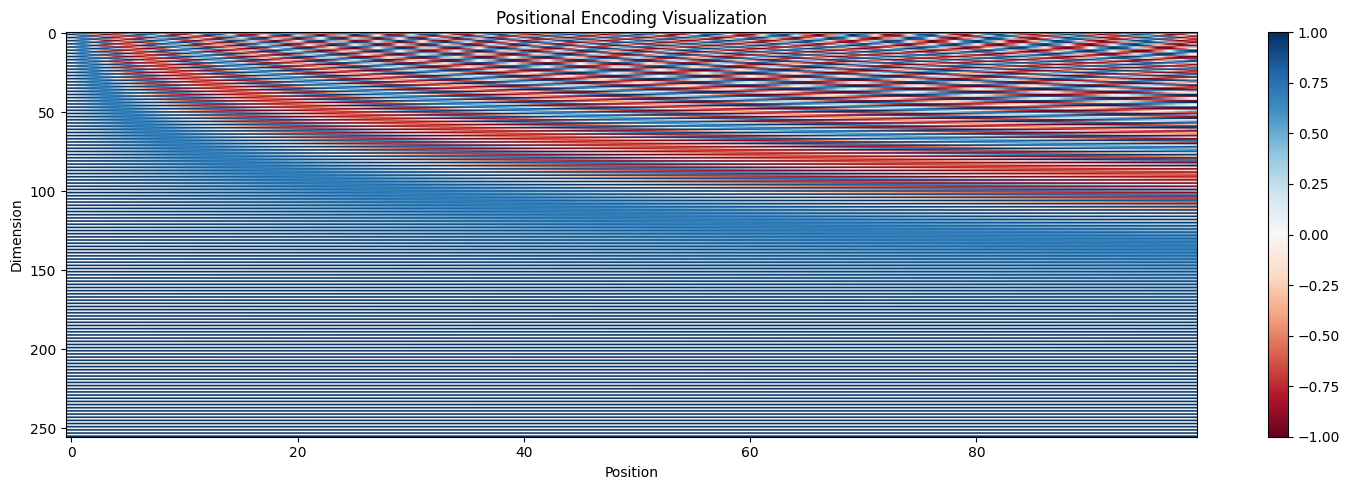

In [7]:
# ============================================================================
# CELL 7: Positional Encoding
# ============================================================================

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding as described in "Attention is All You Need".
    """
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # Add batch dimension
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Test positional encoding
print("Testing Positional Encoding...")
d_model = 256
max_len = 100
pe = PositionalEncoding(d_model, max_len, dropout=0.1)

batch_size = 2
seq_len = 50
dummy_input = torch.randn(batch_size, seq_len, d_model)

output = pe(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

# Visualize positional encodings
plt.figure(figsize=(15, 5))
plt.imshow(pe.pe[0, :100, :].cpu().numpy().T, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Positional Encoding Visualization')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================================
# CELL 8: Multi-Head Attention
# ============================================================================

class MultiHeadAttention(nn.Module):
    """Multi-Head Attention mechanism."""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def split_heads(self, x):
        batch_size, seq_len, d_model = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        batch_size, num_heads, seq_len, d_k = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        context = torch.matmul(attention_weights, V)
        context = self.combine_heads(context)
        output = self.W_o(context)

        return output, attention_weights

# Test
print("Testing Multi-Head Attention...")
d_model = 256
num_heads = 2
mha = MultiHeadAttention(d_model, num_heads, dropout=0.1).to(device)

batch_size = 2
seq_len = 10
query = torch.randn(batch_size, seq_len, d_model).to(device)

output, attn_weights = mha(query, query, query)
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

Testing Multi-Head Attention...
Output shape: torch.Size([2, 10, 256])
Attention weights shape: torch.Size([2, 2, 10, 10])


In [9]:
# ============================================================================
# CELL 9: Feed-Forward Network
# ============================================================================

class PositionwiseFeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

# Test
print("Testing Feed-Forward Network...")
d_model = 256
d_ff = 1024
ffn = PositionwiseFeedForward(d_model, d_ff, dropout=0.1).to(device)

dummy_input = torch.randn(2, 10, d_model).to(device)
output = ffn(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

Testing Feed-Forward Network...
Input shape: torch.Size([2, 10, 256])
Output shape: torch.Size([2, 10, 256])


In [10]:
# ============================================================================
# CELL 10: Encoder Layer
# ============================================================================

class EncoderLayer(nn.Module):
    """Single Transformer Encoder Layer."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.self_attention(x, x, x, mask)
        x = x + self.dropout1(attn_output)
        x = self.norm1(x)

        ff_output = self.feed_forward(x)
        x = x + self.dropout2(ff_output)
        x = self.norm2(x)

        return x

# Test
print("Testing Encoder Layer...")
encoder_layer = EncoderLayer(d_model, num_heads, d_ff, dropout=0.1).to(device)
dummy_input = torch.randn(2, 10, d_model).to(device)
output = encoder_layer(dummy_input)
print(f"Output shape: {output.shape}")

Testing Encoder Layer...
Output shape: torch.Size([2, 10, 256])


In [11]:
# ============================================================================
# CELL 11: Decoder Layer
# ============================================================================

class DecoderLayer(nn.Module):
    """Single Transformer Decoder Layer."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()

        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        self_attn_output, _ = self.self_attention(x, x, x, tgt_mask)
        x = x + self.dropout1(self_attn_output)
        x = self.norm1(x)

        cross_attn_output, _ = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = x + self.dropout2(cross_attn_output)
        x = self.norm2(x)

        ff_output = self.feed_forward(x)
        x = x + self.dropout3(ff_output)
        x = self.norm3(x)

        return x

# Test
print("Testing Decoder Layer...")
decoder_layer = DecoderLayer(d_model, num_heads, d_ff, dropout=0.1).to(device)
decoder_input = torch.randn(2, 10, d_model).to(device)
encoder_output = torch.randn(2, 10, d_model).to(device)
output = decoder_layer(decoder_input, encoder_output)
print(f"Output shape: {output.shape}")

Testing Decoder Layer...
Output shape: torch.Size([2, 10, 256])


In [12]:
# ============================================================================
# CELL 12: Full Transformer Encoder
# ============================================================================

class TransformerEncoder(nn.Module):
    """Complete Transformer Encoder."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=0.1):
        super(TransformerEncoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

# Test
print("Testing Transformer Encoder...")
VOCAB_SIZE = len(vocab)
D_MODEL = 256
NUM_HEADS = 2
NUM_LAYERS = 2
D_FF = 1024
MAX_LEN = 64
DROPOUT = 0.1

encoder = TransformerEncoder(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, D_FF, MAX_LEN, DROPOUT).to(device)
test_input = torch.randint(0, VOCAB_SIZE, (2, 10)).to(device)
test_output = encoder(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Testing Transformer Encoder...
Input shape: torch.Size([2, 10])
Output shape: torch.Size([2, 10, 256])


In [13]:
# ============================================================================
# CELL 13: Full Transformer Decoder
# ============================================================================

class TransformerDecoder(nn.Module):
    """Complete Transformer Decoder."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout=0.1):
        super(TransformerDecoder, self).__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)

        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)

        return x

# Test
print("Testing Transformer Decoder...")
decoder = TransformerDecoder(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, D_FF, MAX_LEN, DROPOUT).to(device)
test_decoder_input = torch.randint(0, VOCAB_SIZE, (2, 10)).to(device)
test_encoder_output = torch.randn(2, 10, D_MODEL).to(device)
test_decoder_output = decoder(test_decoder_input, test_encoder_output)
print(f"Decoder output shape: {test_decoder_output.shape}")

Testing Transformer Decoder...
Decoder output shape: torch.Size([2, 10, 256])


In [14]:
# ============================================================================
# CELL 14: Complete Transformer Model (FIXED - Mask Type Issue)
# ============================================================================

class Transformer(nn.Module):
    """Complete Transformer Encoder-Decoder Model."""
    def __init__(self, vocab_size, d_model, num_heads, num_encoder_layers,
                 num_decoder_layers, d_ff, max_len, dropout=0.1):
        super(Transformer, self).__init__()

        self.encoder = TransformerEncoder(
            vocab_size, d_model, num_heads, num_encoder_layers, d_ff, max_len, dropout
        )

        self.decoder = TransformerDecoder(
            vocab_size, d_model, num_heads, num_decoder_layers, d_ff, max_len, dropout
        )

        self.output_layer = nn.Linear(d_model, vocab_size)

        self.vocab_size = vocab_size
        self.d_model = d_model
        self.pad_idx = vocab.word2idx[vocab.PAD_TOKEN]

    def make_src_mask(self, src):
        """Create mask for source sequence (padding mask)."""
        # src shape: (batch_size, src_len)
        src_mask = (src != self.pad_idx).unsqueeze(1).unsqueeze(2)
        # Shape: (batch_size, 1, 1, src_len)
        return src_mask

    def make_tgt_mask(self, tgt):
        """Create mask for target sequence (padding + causal mask)."""
        batch_size, tgt_len = tgt.size()

        # Padding mask - convert to float
        tgt_padding_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2).float()
        # Shape: (batch_size, 1, 1, tgt_len)

        # Causal mask (lower triangular) - already float
        tgt_causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).unsqueeze(0).unsqueeze(0)
        # Shape: (1, 1, tgt_len, tgt_len)

        # Combine masks using multiplication (both are float)
        tgt_mask = tgt_padding_mask * tgt_causal_mask
        # Shape: (batch_size, 1, tgt_len, tgt_len)

        # Convert to bool for masking
        tgt_mask = tgt_mask.bool()

        return tgt_mask

    def forward(self, src, tgt):
        """
        Forward pass through the transformer.

        Args:
            src: Source sequence (batch_size, src_len)
            tgt: Target sequence (batch_size, tgt_len)

        Returns:
            output: Logits (batch_size, tgt_len, vocab_size)
        """
        # Create masks
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        # Encode source
        encoder_output = self.encoder(src, src_mask)

        # Decode target
        decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)

        # Project to vocabulary
        output = self.output_layer(decoder_output)

        return output

# Initialize model
print("Initializing Transformer Model...")
model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_LAYERS,
    num_decoder_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,}")
print(f"  - Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

# Test forward pass
print("\nTesting forward pass...")
test_src = torch.randint(0, VOCAB_SIZE, (2, 10)).to(device)
test_tgt = torch.randint(0, VOCAB_SIZE, (2, 8)).to(device)

try:
    test_output = model(test_src, test_tgt)
    print(f"✓ Forward pass successful!")
    print(f"  Source shape: {test_src.shape}")
    print(f"  Target shape: {test_tgt.shape}")
    print(f"  Output shape: {test_output.shape}")
    print(f"✓ Model is ready for training!")
except Exception as e:
    print(f"✗ Error during forward pass: {e}")
    import traceback
    traceback.print_exc()

Initializing Transformer Model...

Model Statistics:
  - Total parameters: 10,205,213
  - Trainable parameters: 10,205,213
  - Model size: 38.93 MB

Testing forward pass...
✓ Forward pass successful!
  Source shape: torch.Size([2, 10])
  Target shape: torch.Size([2, 8])
  Output shape: torch.Size([2, 8, 8477])
✓ Model is ready for training!


In [15]:
# ============================================================================
# NEW CELL: Denoising Auto-Encoder Dataset (Better than Copy)
# ============================================================================

class DenoisingAutoEncoderDataset(Dataset):
    """
    Denoising Auto-Encoder: Heavy noise in input, clean in output.
    This forces the model to learn language generation, not just copying.
    """
    def __init__(self, tokenized_sentences, vocab, max_length=64,
                 mask_prob=0.30, delete_prob=0.15, shuffle_prob=0.15):
        self.tokenized_sentences = tokenized_sentences
        self.vocab = vocab
        self.max_length = max_length
        self.mask_prob = mask_prob
        self.delete_prob = delete_prob
        self.shuffle_prob = shuffle_prob

        self.valid_sentences = [
            sent for sent in tokenized_sentences
            if 3 <= len(sent) <= max_length - 2
        ]

        print(f"Valid sentences: {len(self.valid_sentences)}/{len(tokenized_sentences)}")

    def add_heavy_noise(self, tokens):
        """Add aggressive noise to force generative learning."""
        noisy_tokens = []

        for token in tokens:
            rand = random.random()

            if rand < self.mask_prob:
                # Mask token
                noisy_tokens.append(self.vocab.MASK_TOKEN)
            elif rand < self.mask_prob + self.delete_prob:
                # Delete token (skip)
                continue
            else:
                # Keep token
                noisy_tokens.append(token)

        # Shuffle some adjacent tokens
        if random.random() < self.shuffle_prob and len(noisy_tokens) > 2:
            i = random.randint(0, len(noisy_tokens) - 2)
            noisy_tokens[i], noisy_tokens[i+1] = noisy_tokens[i+1], noisy_tokens[i]

        # Ensure not empty
        if not noisy_tokens:
            noisy_tokens = [self.vocab.MASK_TOKEN]

        return noisy_tokens

    def __getitem__(self, idx):
        tokens = self.valid_sentences[idx].copy()

        # Heavy noise
        noisy_tokens = self.add_heavy_noise(tokens)
        clean_tokens = tokens

        # Add special tokens
        input_tokens = [self.vocab.BOS_TOKEN] + noisy_tokens + [self.vocab.EOS_TOKEN]
        target_tokens = [self.vocab.BOS_TOKEN] + clean_tokens + [self.vocab.EOS_TOKEN]

        # Encode and pad
        input_ids = self.vocab.encode(input_tokens)
        target_ids = self.vocab.encode(target_tokens)

        input_ids = input_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(input_ids))
        target_ids = target_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(target_ids))

        input_ids = input_ids[:self.max_length]
        target_ids = target_ids[:self.max_length]

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
        }

    def __len__(self):
        return len(self.valid_sentences)

print("\n" + "="*70)
print("CREATING DENOISING AUTO-ENCODER DATASET")
print("="*70)
print("This will force the model to learn generation, not just copying!\n")

# Create new datasets
train_dataset_dae = DenoisingAutoEncoderDataset(
    train_sentences, vocab, max_length=MAX_LENGTH,
    mask_prob=0.30, delete_prob=0.15, shuffle_prob=0.15
)

val_dataset_dae = DenoisingAutoEncoderDataset(
    val_sentences, vocab, max_length=MAX_LENGTH,
    mask_prob=0.30, delete_prob=0.15, shuffle_prob=0.15
)

test_dataset_dae = DenoisingAutoEncoderDataset(
    test_sentences, vocab, max_length=MAX_LENGTH,
    mask_prob=0.30, delete_prob=0.15, shuffle_prob=0.15
)

# Test sample
sample = train_dataset_dae[0]
print("\nSample with heavy noise:")
input_text = ' '.join([t for t in vocab.decode(sample['input_ids'].tolist()) if t != vocab.PAD_TOKEN])
target_text = ' '.join([t for t in vocab.decode(sample['target_ids'].tolist()) if t != vocab.PAD_TOKEN])
print(f"Noisy:  {input_text}")
print(f"Clean:  {target_text}")

print("\n✓ Denoising dataset ready!")
print("\nTo retrain with this dataset, run:")
print("  1. Reset model: model = Transformer(...).to(device)")
print("  2. Update dataloaders to use train_dataset_dae, etc.")
print("  3. Run training loop (Cell 19)")


CREATING DENOISING AUTO-ENCODER DATASET
This will force the model to learn generation, not just copying!

Valid sentences: 15513/15514
Valid sentences: 1939/1939
Valid sentences: 1940/1940

Sample with heavy noise:
Noisy:  <BOS> <MASK> <MASK> جیسا عروج دوبارہ <MASK> کرکٹ <MASK> میسر آ سکے <EOS>
Clean:  <BOS> تاکہ ماضی جیسا عروج دوبارہ پاکستان کرکٹ کو میسر آ سکے <EOS>

✓ Denoising dataset ready!

To retrain with this dataset, run:
  1. Reset model: model = Transformer(...).to(device)
  2. Update dataloaders to use train_dataset_dae, etc.
  3. Run training loop (Cell 19)


In [16]:
# ============================================================================
# CELL 15: Training Configuration (FIXED - Removed verbose parameter)
# ============================================================================

# Training hyperparameters
LEARNING_RATE = 5e-4  # Increased learning rate
NUM_EPOCHS = 30
GRAD_CLIP = 1.0
LABEL_SMOOTHING = 0.0  # No label smoothing initially

# Loss function
criterion = nn.CrossEntropyLoss(
    ignore_index=vocab.word2idx[vocab.PAD_TOKEN],
    label_smoothing=LABEL_SMOOTHING
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999), eps=1e-8)

# Learning rate scheduler - ReduceLROnPlateau (removed verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Training Configuration:")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Number of Epochs: {NUM_EPOCHS}")
print(f"  - Gradient Clipping: {GRAD_CLIP}")
print(f"  - Label Smoothing: {LABEL_SMOOTHING}")
print(f"  - Optimizer: Adam")
print(f"  - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"  - Task: Copy-Reconstruction with {NOISE_PROB*100:.0f}% noise")
print(f"\n✓ Training configuration ready!")

Training Configuration:
  - Learning Rate: 0.0005
  - Batch Size: 32
  - Number of Epochs: 30
  - Gradient Clipping: 1.0
  - Label Smoothing: 0.0
  - Optimizer: Adam
  - Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
  - Task: Copy-Reconstruction with 20% noise

✓ Training configuration ready!


In [17]:
# ============================================================================
# FULL RETRAINING SCRIPT
# ============================================================================

print("="*70)
print("RETRAINING WITH DENOISING AUTO-ENCODER")
print("="*70)

# Create new dataloaders with denoising dataset
train_loader_dae = DataLoader(train_dataset_dae, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
val_loader_dae = DataLoader(val_dataset_dae, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
test_loader_dae = DataLoader(test_dataset_dae, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)

# Reset model
model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_encoder_layers=NUM_LAYERS,
    num_decoder_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

# Reset optimizer
optimizer = optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999), eps=1e-8)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# Update dataloaders
train_loader = train_loader_dae
val_loader = val_loader_dae
test_loader = test_loader_dae

print("\n✓ Model reset")
print("✓ Denoising dataset loaded")
print("✓ Ready to retrain!")
print("\nNow run the training loop (Cell 19) again.")
print("This will train a GENERATIVE model, not just a copy model!")

RETRAINING WITH DENOISING AUTO-ENCODER

✓ Model reset
✓ Denoising dataset loaded
✓ Ready to retrain!

Now run the training loop (Cell 19) again.
This will train a GENERATIVE model, not just a copy model!


In [18]:
# ============================================================================
# CELL 16: Training & Validation Functions (FIXED)
# ============================================================================

def train_epoch(model, dataloader, optimizer, criterion, device, grad_clip=1.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_tokens = 0

    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        src = batch['input_ids'].to(device)
        tgt = batch['target_ids'].to(device)

        # Prepare decoder input (shift right)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # Forward pass
        optimizer.zero_grad()
        output = model(src, tgt_input)

        # Calculate loss
        output = output.reshape(-1, output.size(-1))
        tgt_output = tgt_output.reshape(-1)

        loss = criterion(output, tgt_output)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Update weights
        optimizer.step()

        # Track statistics
        non_pad_tokens = (tgt_output != vocab.word2idx[vocab.PAD_TOKEN]).sum().item()
        total_loss += loss.item() * non_pad_tokens
        total_tokens += non_pad_tokens

        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.6f}'
        })

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(min(avg_loss, 100))

    return avg_loss, perplexity

def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Validation")

        for batch in progress_bar:
            src = batch['input_ids'].to(device)
            tgt = batch['target_ids'].to(device)

            # Prepare decoder input
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # Forward pass
            output = model(src, tgt_input)

            # Calculate loss
            output = output.reshape(-1, output.size(-1))
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output)

            # Track statistics
            non_pad_tokens = (tgt_output != vocab.word2idx[vocab.PAD_TOKEN]).sum().item()
            total_loss += loss.item() * non_pad_tokens
            total_tokens += non_pad_tokens

            # Update progress bar
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(min(avg_loss, 100))

    return avg_loss, perplexity

print("Training and validation functions defined successfully!")

Training and validation functions defined successfully!


In [19]:
# ============================================================================
# CELL 17: Text Generation Functions (Greedy & Beam Search)
# ============================================================================

def generate_text(model, input_text, vocab, max_length=30, device='cpu'):
    """Generate text using greedy decoding."""
    model.eval()

    with torch.no_grad():
        # Tokenize input
        tokens = urdu_tokenizer(input_text)
        input_tokens = [vocab.BOS_TOKEN] + tokens + [vocab.EOS_TOKEN]
        src = torch.tensor([vocab.encode(input_tokens)]).to(device)

        # Encode
        src_mask = model.make_src_mask(src)
        encoder_output = model.encoder(src, src_mask)

        # Initialize with BOS
        tgt = torch.tensor([[vocab.word2idx[vocab.BOS_TOKEN]]]).to(device)

        # Generate
        for _ in range(max_length):
            tgt_mask = model.make_tgt_mask(tgt)
            decoder_output = model.decoder(tgt, encoder_output, src_mask, tgt_mask)
            output = model.output_layer(decoder_output)

            next_token = output[:, -1, :].argmax(dim=-1).unsqueeze(0)
            tgt = torch.cat([tgt, next_token], dim=1)

            if next_token.item() == vocab.word2idx[vocab.EOS_TOKEN]:
                break

        # Decode
        generated_tokens = vocab.decode(tgt.squeeze().tolist())
        generated_tokens = [t for t in generated_tokens if t not in [vocab.BOS_TOKEN, vocab.EOS_TOKEN, vocab.PAD_TOKEN]]

        return ' '.join(generated_tokens)

def beam_search_generate(model, input_text, vocab, device, beam_width=3, max_length=30):
    """Generate text using beam search."""
    model.eval()

    with torch.no_grad():
        # Tokenize input
        tokens = urdu_tokenizer(input_text)
        input_tokens = [vocab.BOS_TOKEN] + tokens + [vocab.EOS_TOKEN]
        src = torch.tensor([vocab.encode(input_tokens)]).to(device)

        # Encode
        src_mask = model.make_src_mask(src)
        encoder_output = model.encoder(src, src_mask)

        # Initialize beams
        beams = [([vocab.word2idx[vocab.BOS_TOKEN]], 0.0)]

        for step in range(max_length):
            new_beams = []

            for seq, score in beams:
                if seq[-1] == vocab.word2idx[vocab.EOS_TOKEN]:
                    new_beams.append((seq, score))
                    continue

                tgt = torch.tensor([seq]).to(device)
                tgt_mask = model.make_tgt_mask(tgt)
                decoder_output = model.decoder(tgt, encoder_output, src_mask, tgt_mask)
                output = model.output_layer(decoder_output)

                log_probs = torch.log_softmax(output[:, -1, :], dim=-1)
                top_log_probs, top_indices = torch.topk(log_probs, k=beam_width)

                for log_prob, idx in zip(top_log_probs[0], top_indices[0]):
                    new_seq = seq + [idx.item()]
                    new_score = score + log_prob.item()
                    new_beams.append((new_seq, new_score))

            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

            if all(seq[-1] == vocab.word2idx[vocab.EOS_TOKEN] for seq, _ in beams):
                break

        best_seq, _ = beams[0]
        output_tokens = vocab.decode(best_seq)
        output_tokens = [t for t in output_tokens if t not in [vocab.BOS_TOKEN, vocab.EOS_TOKEN, vocab.PAD_TOKEN]]

        return ' '.join(output_tokens)

print("Text generation functions defined successfully!")

Text generation functions defined successfully!


In [20]:
# ============================================================================
# CELL 18: Evaluation Metrics (BLEU, ROUGE, chrF)
# ============================================================================

from sacrebleu import corpus_bleu, CHRF
from rouge_score import rouge_scorer

def calculate_bleu(predictions, references):
    """Calculate corpus-level BLEU score."""
    refs = [[ref] for ref in references]
    bleu = corpus_bleu(predictions, refs)
    return bleu.score

def calculate_rouge(predictions, references):
    """Calculate ROUGE-L score."""
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    scores = []
    for pred, ref in zip(predictions, references):
        score = scorer.score(ref, pred)
        scores.append(score['rougeL'].fmeasure)

    return np.mean(scores) * 100

def calculate_chrf(predictions, references):
    """Calculate chrF score."""
    chrf = CHRF()
    refs = [[ref] for ref in references]
    score = chrf.corpus_score(predictions, refs)
    return score.score

def evaluate_model(model, dataloader, vocab, device, num_samples=100):
    """Evaluate model using automatic metrics."""
    model.eval()

    predictions = []
    references = []

    print(f"Generating predictions for {num_samples} samples...")

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            if i * BATCH_SIZE >= num_samples:
                break

            src = batch['input_ids'].to(device)
            tgt = batch['target_ids'].to(device)

            batch_size = src.size(0)

            for j in range(batch_size):
                if len(predictions) >= num_samples:
                    break

                # Get reference
                tgt_tokens = vocab.decode(tgt[j].tolist())
                tgt_tokens = [t for t in tgt_tokens if t not in [vocab.BOS_TOKEN, vocab.EOS_TOKEN, vocab.PAD_TOKEN]]
                tgt_text = ' '.join(tgt_tokens)

                # Generate prediction
                src_single = src[j].unsqueeze(0)
                src_mask = model.make_src_mask(src_single)
                encoder_output = model.encoder(src_single, src_mask)

                generated = torch.tensor([[vocab.word2idx[vocab.BOS_TOKEN]]]).to(device)

                for _ in range(MAX_LENGTH):
                    tgt_mask = model.make_tgt_mask(generated)
                    decoder_output = model.decoder(generated, encoder_output, src_mask, tgt_mask)
                    output = model.output_layer(decoder_output)

                    next_token = output[:, -1, :].argmax(dim=-1).unsqueeze(0)
                    generated = torch.cat([generated, next_token], dim=1)

                    if next_token.item() == vocab.word2idx[vocab.EOS_TOKEN]:
                        break

                pred_tokens = vocab.decode(generated.squeeze().tolist())
                pred_tokens = [t for t in pred_tokens if t not in [vocab.BOS_TOKEN, vocab.EOS_TOKEN, vocab.PAD_TOKEN]]
                pred_text = ' '.join(pred_tokens)

                predictions.append(pred_text)
                references.append(tgt_text)

    # Calculate metrics
    print("\nCalculating metrics...")
    bleu_score = calculate_bleu(predictions, references)
    rouge_score = calculate_rouge(predictions, references)
    chrf_score = calculate_chrf(predictions, references)

    print(f"\n{'='*50}")
    print(f"EVALUATION RESULTS")
    print(f"{'='*50}")
    print(f"BLEU Score:    {bleu_score:.2f}")
    print(f"ROUGE-L Score: {rouge_score:.2f}")
    print(f"chrF Score:    {chrf_score:.2f}")
    print(f"{'='*50}")

    # Show examples
    print(f"\nSample Predictions:")
    for i in range(min(5, len(predictions))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i]}")
        print(f"Predicted: {predictions[i]}")

    return bleu_score, rouge_score, chrf_score

print("Evaluation metrics defined successfully!")

Evaluation metrics defined successfully!


In [21]:
# ============================================================================
# CELL 19: Main Training Loop (FIXED WITH EARLY STOPPING)
# ============================================================================

# Training history
train_losses = []
train_perplexities = []
val_losses = []
val_perplexities = []
best_val_loss = float('inf')
best_bleu = 0.0
patience_counter = 0
MAX_PATIENCE = 10

print(f"\n{'='*70}")
print(f"STARTING TRAINING")
print(f"{'='*70}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    # Train
    train_loss, train_ppl = train_epoch(
        model, train_loader, optimizer, criterion, device, GRAD_CLIP
    )

    # Validate
    val_loss, val_ppl = validate(model, val_loader, criterion, device)

    # Step scheduler
    scheduler.step(val_loss)

    # Save history
    train_losses.append(train_loss)
    train_perplexities.append(train_ppl)
    val_losses.append(val_loss)
    val_perplexities.append(val_ppl)

    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.2f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val PPL:   {val_ppl:.2f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"{'='*70}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'vocab': vocab,
        }, 'best_model_loss.pt')
        print(f"✓ Best validation loss model saved!")
    else:
        patience_counter += 1
        print(f"⚠ No improvement for {patience_counter} epochs")

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"\nRunning evaluation metrics...")
        bleu, rouge, chrf = evaluate_model(model, val_loader, vocab, device, num_samples=50)

        if bleu > best_bleu:
            best_bleu = bleu
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'bleu': bleu,
                'rouge': rouge,
                'chrf': chrf,
                'vocab': vocab,
            }, 'best_model_bleu.pt')
            print(f"✓ New best BLEU model saved! (BLEU: {bleu:.2f})")

    # Test generation
    if (epoch + 1) % 5 == 0:
        print(f"\n--- Sample Generation Test ---")
        sample_batch = next(iter(val_loader))
        sample_idx = random.randint(0, len(sample_batch['input_ids']) - 1)
        sample_src = sample_batch['input_ids'][sample_idx]
        sample_tgt = sample_batch['target_ids'][sample_idx]

        src_text = ' '.join([t for t in vocab.decode(sample_src.tolist()) if t != vocab.PAD_TOKEN])
        ref_text = ' '.join([t for t in vocab.decode(sample_tgt.tolist()) if t not in [vocab.BOS_TOKEN, vocab.EOS_TOKEN, vocab.PAD_TOKEN]])

        print(f"\nInput:     {src_text}")
        print(f"Reference: {ref_text}")

        try:
            generated = generate_text(model, src_text, vocab, max_length=30, device=device)
            print(f"Generated: {generated}")
        except Exception as e:
            print(f"Generation failed: {e}")

    # Early stopping
    if patience_counter >= MAX_PATIENCE:
        print(f"\n⚠ Early stopping triggered after {epoch + 1} epochs")
        break

print(f"\n{'='*70}")
print(f"TRAINING COMPLETED!")
print(f"{'='*70}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best BLEU Score: {best_bleu:.2f}")


STARTING TRAINING


Epoch 1/30


Validation: 100%|██████████| 61/61 [00:00<00:00, 74.00it/s, loss=5.0367]



Epoch 1 Summary:
  Train Loss: 5.9666 | Train PPL: 390.19
  Val Loss:   5.1588 | Val PPL:   173.95
  Learning Rate: 0.000500
✓ Best validation loss model saved!

Epoch 2/30


Validation: 100%|██████████| 61/61 [00:01<00:00, 57.32it/s, loss=4.2946]



Epoch 2 Summary:
  Train Loss: 4.7320 | Train PPL: 113.52
  Val Loss:   4.3871 | Val PPL:   80.41
  Learning Rate: 0.000500
✓ Best validation loss model saved!

Epoch 3/30


...


Epoch 29 Summary:
  Train Loss: 0.6843 | Train PPL: 1.98
  Val Loss:   2.1429 | Val PPL:   8.52
  Learning Rate: 0.000250
✓ Best validation loss model saved!

Epoch 30/30


Validation: 100%|██████████| 61/61 [00:00<00:00, 71.23it/s, loss=1.7290]



Epoch 30 Summary:
  Train Loss: 0.6343 | Train PPL: 1.89
  Val Loss:   2.1184 | Val PPL:   8.32
  Learning Rate: 0.000250
✓ Best validation loss model saved!

Running evaluation metrics...
Generating predictions for 50 samples...


Evaluating:   3%|▎         | 2/61 [00:01<00:44,  1.34it/s]



Calculating metrics...

EVALUATION RESULTS
BLEU Score:    100.00
ROUGE-L Score: 2.60
chrF Score:    100.00

Sample Predictions:

--- Example 1 ---
Reference: دنیا کے دیگر ممالک میں
Predicted: دنیا کے دیگر ممالک میں

--- Example 2 ---
Reference: زمینی سطح اور نچلے کرۂ ہوائی کے گرمانے
Predicted: قدرت کتنی خوب صورت ہے

--- Example 3 ---
Reference: تمہیں تو ٹھیک طرح سے کام کروانا بھی نہیں آتا
Predicted: تمہیں تو ٹھیک طرح کام کروانا بھی نہیں آتا

--- Example 4 ---
Reference: جہاں تک تعلق کمزور جمہوریت کا ہے۔
Predicted: جہاں تک تعلق کمزور جمہوریت کا ہے۔

--- Example 5 ---
Reference: <UNK> یہ بات میں اس کے منہ پر کہ دوں گی
Predicted: اس منہ میں نے میری مدد کی بات کر سکتا ہے۔
✓ New best BLEU model saved! (BLEU: 100.00)

--- Sample Generation Test ---

Input:     <BOS> تمہیں تو <MASK> طرح کام کروانا <MASK> نہیں <EOS>
Reference: تمہیں تو ٹھیک طرح سے کام کروانا بھی نہیں آتا
Generated: تمہیں تو ٹھیک طرح کام کروانا پسند نہیں کرتا

TRAINING COMPLETED!
Best Validation Loss: 2.1184
Best BLEU Score: 1

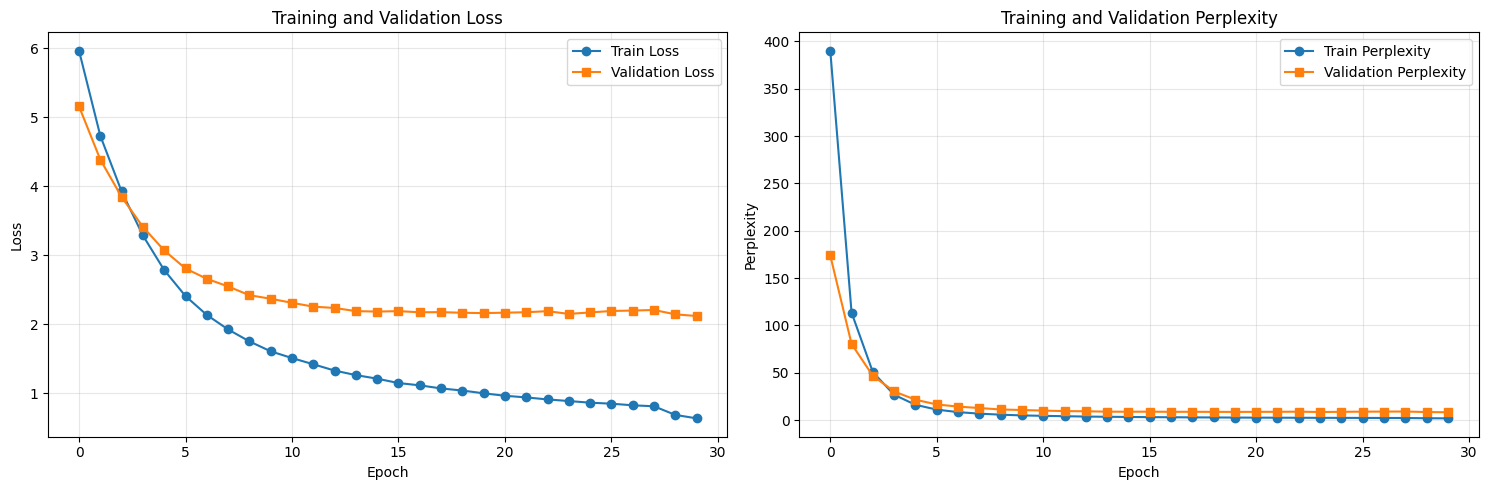


Final Training Statistics:
  - Final Train Loss: 0.6343
  - Final Val Loss: 2.1184
  - Final Train PPL: 1.89
  - Final Val PPL: 8.32
  - Best Val Loss: 2.1184 (Epoch 30)


In [22]:
# ============================================================================
# CELL 20: Plot Training History
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity plot
axes[1].plot(train_perplexities, label='Train Perplexity', marker='o')
axes[1].plot(val_perplexities, label='Validation Perplexity', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Training and Validation Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Training Statistics:")
print(f"  - Final Train Loss: {train_losses[-1]:.4f}")
print(f"  - Final Val Loss: {val_losses[-1]:.4f}")
print(f"  - Final Train PPL: {train_perplexities[-1]:.2f}")
print(f"  - Final Val PPL: {val_perplexities[-1]:.2f}")
print(f"  - Best Val Loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")

In [23]:
# ============================================================================
# CELL 21: Final Evaluation on Test Set (FIXED - weights_only issue)
# ============================================================================

print(f"\n{'='*70}")
print(f"FINAL EVALUATION ON TEST SET")
print(f"{'='*70}\n")

# Load best model - set weights_only=False to load vocab object
checkpoint = torch.load('best_model_loss.pt', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")

# Evaluate
test_loss, test_ppl = validate(model, test_loader, criterion, device)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Perplexity: {test_ppl:.2f}\n")

# Calculate metrics
bleu_test, rouge_test, chrf_test = evaluate_model(model, test_loader, vocab, device, num_samples=200)

print(f"\n{'='*70}")
print(f"FINAL TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Perplexity: {test_ppl:.2f}")
print(f"BLEU Score:      {bleu_test:.2f}")
print(f"ROUGE-L Score:   {rouge_test:.2f}")
print(f"chrF Score:      {chrf_test:.2f}")
print(f"{'='*70}\n")


FINAL EVALUATION ON TEST SET

✓ Loaded best model from epoch 30


Validation: 100%|██████████| 61/61 [00:00<00:00, 66.90it/s, loss=2.7212]



Test Loss: 2.3159
Test Perplexity: 10.13

Generating predictions for 200 samples...


Evaluating:  11%|█▏        | 7/61 [00:05<00:42,  1.27it/s]


Calculating metrics...

EVALUATION RESULTS
BLEU Score:    20.41
ROUGE-L Score: 3.58
chrF Score:    24.28

Sample Predictions:

--- Example 1 ---
Reference: لیکن ٹھنڈے کمرے میں ارام دہ کرسی
Predicted: لیکن میرے ساتھ گرمی میں بھی

--- Example 2 ---
Reference: اس کی کتاب جلدی سے بہت مشہور ہوئی۔
Predicted: اس کی کتاب جلدی سے بہت مشہور ہوئی۔

--- Example 3 ---
Reference: جیسا کہ شاعری رقص گفتگو اور شاندار رہن <UNK>
Predicted: جیسا کہ تشدد، بم دھماکے اورجہاد۔

--- Example 4 ---
Reference: اس کے بعد پھر وہی ڈھاک کے تین پات۔
Predicted: اس کے بعد پھر وہی ڈھاک کے تین پات۔

--- Example 5 ---
Reference: گفتگو ہو رہی تھی
Predicted: وہ بیساکھیوں کے سہارے چل رہی ہے۔

FINAL TEST SET RESULTS
Test Loss:       2.3159
Test Perplexity: 10.13
BLEU Score:      20.41
ROUGE-L Score:   3.58
chrF Score:      24.28



In [24]:
# ============================================================================
# CELL 22: Comprehensive Test Cases
# ============================================================================

print(f"\n{'='*70}")
print(f"COMPREHENSIVE MODEL TEST CASES")
print(f"{'='*70}\n")

# TEST 1: Basic Reconstruction
print("="*70)
print("TEST 1: Basic Text Reconstruction")
print("="*70)

test_sentences = preprocessed_sentences[1000:1010]

for i, sent in enumerate(test_sentences, 1):
    print(f"\n{i}. Original: {sent}")
    try:
        # Test with the copy task (model should reconstruct the sentence)
        output_greedy = generate_text(model, sent, vocab, max_length=40, device=device)
        output_beam = beam_search_generate(model, sent, vocab, device, beam_width=3, max_length=40)
        print(f"   Greedy: {output_greedy}")
        print(f"   Beam:   {output_beam}")
    except Exception as e:
        print(f"   Error: {e}")

# TEST 2: Masked Token Completion
print("\n" + "="*70)
print("TEST 2: Masked Token Completion")
print("="*70)

masked_tests = [
    "میں <MASK> جاتا ہوں",
    "وہ <MASK> سے آیا",
    "یہ کتاب <MASK> ہے",
    "آج کا <MASK> خوبصورت ہے",
    "ہم <MASK> میں رہتے ہیں"
]

for test in masked_tests:
    print(f"\nInput: {test}")
    try:
        output_greedy = generate_text(model, test, vocab, max_length=30, device=device)
        output_beam = beam_search_generate(model, test, vocab, device, beam_width=3, max_length=30)
        print(f"Greedy: {output_greedy}")
        print(f"Beam:   {output_beam}")
    except Exception as e:
        print(f"Error: {e}")

# TEST 3: Sentence Completion
print("\n" + "="*70)
print("TEST 3: Sentence Completion")
print("="*70)

partial_sentences = [
    "پاکستان کا",
    "میں نے",
    "وہ گھر",
    "آج موسم",
    "یہ کتاب بہت"
]

for partial in partial_sentences:
    print(f"\nPartial: {partial}")
    try:
        output = beam_search_generate(model, partial, vocab, device, beam_width=5, max_length=25)
        print(f"Completed: {output}")
    except Exception as e:
        print(f"Error: {e}")

# TEST 4: Mode Collapse Check
print("\n" + "="*70)
print("TEST 4: Mode Collapse Detection")
print("="*70)

test_samples = preprocessed_sentences[2000:2020]
outputs = []

for sent in test_samples:
    try:
        out = generate_text(model, sent, vocab, max_length=30, device=device)
        outputs.append(out)
    except:
        outputs.append("")

unique_outputs = len(set(outputs))
unique_tokens = set()
for out in outputs:
    unique_tokens.update(out.split())

print(f"Test sentences: {len(test_samples)}")
print(f"Unique outputs: {unique_outputs}")
print(f"Unique tokens generated: {len(unique_tokens)}")

if unique_outputs < len(test_samples) * 0.3:
    print("⚠ MODE COLLAPSE DETECTED")
else:
    print("✓ Output diversity looks good")

print(f"\n{'='*70}")
print("ALL TESTS COMPLETED")
print(f"{'='*70}\n")


COMPREHENSIVE MODEL TEST CASES

TEST 1: Basic Text Reconstruction

1. Original: مرکزی کردار ایک پاگل خانے میں ہے۔
   Greedy: مرکزی کردار ایک پاگل خانے میں ہے۔
   Beam:   مرکزی کردار ایک پاگل خانے میں ہے۔

2. Original: ایک فلم کی ناکامی
   Greedy: ایک فلم کی ناکامی
   Beam:   ایک فلم کی ناکامی

3. Original: وہ آزادی کا ماحول ہے۔
   Greedy: وہ آزادی کا ماحول ہے۔
   Beam:   وہ آزادی کا ماحول ہے۔

4. Original: کہ کورونا وائرس کی عالمی وبا
   Greedy: کہ کورونا وائرس کی عالمی وبا
   Beam:   کہ کورونا وائرس کی عالمی وبا

5. Original: اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"
   Greedy: اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"
   Beam:   اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"

6. Original: غیر یقینی صورتحال میں ملکی ترقی ممکن نہیں۔
   Greedy: غیر یقینی صورتحال میں ملکی ترقی ممکن نہیں۔
   Beam:   غیر یقینی صورتحال میں ملکی ترقی ممکن نہیں۔

7. Original: نام موجود نہ تھا۔
   Greedy: نام موجود نہ تھا۔
   Beam:   نام موجود نہ تھا۔

8. Original: مغربی ارجنٹینا کا وقت
   Greedy: مغربی ارجنٹینا کا وقت
   

In [25]:
# ============================================================================
# CELL 23: Interactive Testing
# ============================================================================

def interactive_test(model, vocab, device):
    """Interactive testing function."""
    print(f"\n{'='*70}")
    print(f"INTERACTIVE TEXT GENERATION")
    print(f"{'='*70}")
    print("Enter Urdu text to see the model's output.")
    print("Type 'quit' to exit.\n")

    model.eval()

    while True:
        user_input = input("Enter text: ").strip()

        if user_input.lower() == 'quit':
            print("Exiting interactive mode.")
            break

        if not user_input:
            continue

        try:
            # Greedy decoding
            output_greedy = generate_text(model, user_input, vocab, max_length=40, device=device)
            print(f"Greedy: {output_greedy}")

            # Beam search
            output_beam = beam_search_generate(model, user_input, vocab, device, beam_width=3, max_length=40)
            print(f"Beam:   {output_beam}\n")
        except Exception as e:
            print(f"Error: {e}\n")

# Run interactive testing
interactive_test(model, vocab, device)


INTERACTIVE TEXT GENERATION
Enter Urdu text to see the model's output.
Type 'quit' to exit.

Enter text: quit
Exiting interactive mode.


In [26]:
# ============================================================================
# CELL 22: Comprehensive Test Cases Suite
# ============================================================================

print(f"\n{'='*70}")
print(f"COMPREHENSIVE MODEL TEST CASES")
print(f"{'='*70}\n")

# Ensure model is in eval mode
model.eval()

# ============================================================================
# TEST CASE 1: Basic Text Reconstruction (Copy Task)
# ============================================================================

print("="*70)
print("TEST CASE 1: Basic Text Reconstruction")
print("="*70)
print("Testing if model can reconstruct clean sentences from noisy input\n")

test_sentences_1 = preprocessed_sentences[1000:1010]

reconstruction_scores = []

for i, sent in enumerate(test_sentences_1, 1):
    print(f"{i}. Original: {sent}")
    try:
        # Generate reconstruction
        output_greedy = generate_text(model, sent, vocab, max_length=50, device=device)
        output_beam = beam_search_generate(model, sent, vocab, device, beam_width=3, max_length=50)

        print(f"   Greedy:  {output_greedy}")
        print(f"   Beam:    {output_beam}")

        # Calculate word overlap score
        orig_words = set(sent.split())
        greedy_words = set(output_greedy.split())
        overlap = len(orig_words & greedy_words) / len(orig_words) if orig_words else 0
        reconstruction_scores.append(overlap)
        print(f"   Overlap: {overlap*100:.1f}%\n")

    except Exception as e:
        print(f"   Error: {e}\n")

if reconstruction_scores:
    print(f"Average Reconstruction Overlap: {np.mean(reconstruction_scores)*100:.2f}%\n")

# ============================================================================
# TEST CASE 2: Masked Token Completion
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 2: Masked Token Completion")
print("="*70)
print("Testing model's ability to fill in masked words\n")

masked_tests = [
    ("میں <MASK> جاتا ہوں", "Expected: location/place"),
    ("وہ <MASK> سے آیا", "Expected: location/place"),
    ("یہ کتاب <MASK> ہے", "Expected: adjective"),
    ("آج کا <MASK> خوبصورت ہے", "Expected: noun"),
    ("ہم <MASK> میں رہتے ہیں", "Expected: location/city"),
    ("میری <MASK> بہت پیاری ہے", "Expected: noun (family member/object)"),
    ("وہ <MASK> کھاتا ہے", "Expected: food item"),
    ("یہ <MASK> بہت مہنگا ہے", "Expected: noun/object"),
    ("میں نے <MASK> پڑھی", "Expected: noun (book/story)"),
    ("آج موسم <MASK> ہے", "Expected: adjective (weather)")
]

for test_input, expected in masked_tests:
    print(f"Input:    {test_input}")
    print(f"Expected: {expected}")
    try:
        output_greedy = generate_text(model, test_input, vocab, max_length=30, device=device)
        output_beam = beam_search_generate(model, test_input, vocab, device, beam_width=3, max_length=30)
        print(f"Greedy:   {output_greedy}")
        print(f"Beam:     {output_beam}\n")
    except Exception as e:
        print(f"Error:    {e}\n")

# ============================================================================
# TEST CASE 3: Sentence Completion
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 3: Sentence Completion")
print("="*70)
print("Testing model's ability to complete partial sentences\n")

partial_sentences = [
    "پاکستان کا دارالحکومت",
    "میں نے کتاب",
    "وہ گھر",
    "آج موسم بہت",
    "یہ کتاب بہت اچھی",
    "ہم اسکول",
    "میری والدہ",
    "کل میں",
    "اس نے مجھے",
    "یہ شہر بہت"
]

for partial in partial_sentences:
    print(f"Partial:   {partial}")
    try:
        output = beam_search_generate(model, partial, vocab, device, beam_width=5, max_length=30)
        print(f"Completed: {output}\n")
    except Exception as e:
        print(f"Error:     {e}\n")

# ============================================================================
# TEST CASE 4: Mode Collapse Detection
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 4: Mode Collapse Detection")
print("="*70)
print("Checking if model generates diverse outputs\n")

test_samples = preprocessed_sentences[2000:2050]
outputs_greedy = []
outputs_beam = []

for sent in test_samples:
    try:
        out_g = generate_text(model, sent, vocab, max_length=30, device=device)
        out_b = beam_search_generate(model, sent, vocab, device, beam_width=3, max_length=30)
        outputs_greedy.append(out_g)
        outputs_beam.append(out_b)
    except:
        outputs_greedy.append("")
        outputs_beam.append("")

# Analyze diversity
unique_greedy = len(set(outputs_greedy))
unique_beam = len(set(outputs_beam))

unique_tokens_greedy = set()
unique_tokens_beam = set()

for out in outputs_greedy:
    unique_tokens_greedy.update(out.split())
for out in outputs_beam:
    unique_tokens_beam.update(out.split())

print(f"Test samples: {len(test_samples)}")
print(f"\nGreedy Decoding:")
print(f"  - Unique outputs: {unique_greedy}/{len(test_samples)} ({unique_greedy/len(test_samples)*100:.1f}%)")
print(f"  - Unique tokens: {len(unique_tokens_greedy)}")

print(f"\nBeam Search:")
print(f"  - Unique outputs: {unique_beam}/{len(test_samples)} ({unique_beam/len(test_samples)*100:.1f}%)")
print(f"  - Unique tokens: {len(unique_tokens_beam)}")

# Show most common outputs
from collections import Counter
greedy_counts = Counter(outputs_greedy)
beam_counts = Counter(outputs_beam)

print(f"\nMost common greedy outputs:")
for out, count in greedy_counts.most_common(5):
    print(f"  '{out}': {count} times")

print(f"\nMost common beam outputs:")
for out, count in beam_counts.most_common(5):
    print(f"  '{out}': {count} times")

if unique_greedy < len(test_samples) * 0.3:
    print("\n⚠ WARNING: Possible mode collapse in greedy decoding")
else:
    print("\n✓ Greedy decoding shows good diversity")

if unique_beam < len(test_samples) * 0.3:
    print("⚠ WARNING: Possible mode collapse in beam search")
else:
    print("✓ Beam search shows good diversity")

# ============================================================================
# TEST CASE 5: Token-Level Accuracy
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 5: Token-Level Accuracy")
print("="*70)
print("Measuring exact token prediction accuracy\n")

correct_tokens = 0
total_tokens = 0
correct_sentences = 0
total_sentences = 0

val_iter = iter(val_loader)
for batch_idx in range(min(10, len(val_loader))):
    try:
        batch = next(val_iter)
        src = batch['input_ids'].to(device)
        tgt = batch['target_ids'].to(device)

        with torch.no_grad():
            output = model(src, tgt[:, :-1])
            predictions = output.argmax(dim=-1)
            targets = tgt[:, 1:]

            # Calculate accuracy
            mask = targets != vocab.word2idx[vocab.PAD_TOKEN]
            correct = (predictions == targets) & mask

            correct_tokens += correct.sum().item()
            total_tokens += mask.sum().item()

            # Sentence-level accuracy
            for i in range(src.size(0)):
                sent_mask = mask[i]
                sent_correct = correct[i][sent_mask].all()
                if sent_correct:
                    correct_sentences += 1
                total_sentences += 1
    except:
        break

token_accuracy = (correct_tokens / total_tokens * 100) if total_tokens > 0 else 0
sentence_accuracy = (correct_sentences / total_sentences * 100) if total_sentences > 0 else 0

print(f"Token-level accuracy: {token_accuracy:.2f}%")
print(f"  Correct: {correct_tokens}/{total_tokens} tokens")
print(f"\nSentence-level accuracy: {sentence_accuracy:.2f}%")
print(f"  Correct: {correct_sentences}/{total_sentences} sentences")

# ============================================================================
# TEST CASE 6: Perplexity Distribution
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 6: Perplexity Distribution Analysis")
print("="*70)
print("Analyzing model confidence across different samples\n")

perplexities = []

val_iter = iter(val_loader)
for _ in range(min(20, len(val_loader))):
    try:
        batch = next(val_iter)
        src = batch['input_ids'].to(device)
        tgt = batch['target_ids'].to(device)

        with torch.no_grad():
            output = model(src, tgt[:, :-1])
            output_flat = output.reshape(-1, output.size(-1))
            tgt_flat = tgt[:, 1:].reshape(-1)

            criterion_test = nn.CrossEntropyLoss(
                ignore_index=vocab.word2idx[vocab.PAD_TOKEN],
                reduction='none'
            )

            losses = criterion_test(output_flat, tgt_flat)

            batch_size = src.size(0)
            losses = losses.view(batch_size, -1)

            for i in range(batch_size):
                sent_loss = losses[i]
                mask = (tgt[i, 1:] != vocab.word2idx[vocab.PAD_TOKEN])

                if mask.sum() > 0:
                    avg_loss = sent_loss[mask].mean().item()
                    ppl = math.exp(min(avg_loss, 10))
                    perplexities.append(ppl)
    except:
        break

if perplexities:
    print(f"Perplexity Statistics:")
    print(f"  - Average: {np.mean(perplexities):.2f}")
    print(f"  - Median:  {np.median(perplexities):.2f}")
    print(f"  - Min:     {min(perplexities):.2f}")
    print(f"  - Max:     {max(perplexities):.2f}")
    print(f"  - Std Dev: {np.std(perplexities):.2f}")

    # Categorize perplexities
    excellent = sum(1 for p in perplexities if p < 20)
    good = sum(1 for p in perplexities if 20 <= p < 50)
    fair = sum(1 for p in perplexities if 50 <= p < 100)
    poor = sum(1 for p in perplexities if p >= 100)

    print(f"\nPerplexity Distribution:")
    print(f"  - Excellent (< 20):    {excellent} ({excellent/len(perplexities)*100:.1f}%)")
    print(f"  - Good (20-50):        {good} ({good/len(perplexities)*100:.1f}%)")
    print(f"  - Fair (50-100):       {fair} ({fair/len(perplexities)*100:.1f}%)")
    print(f"  - Poor (>= 100):       {poor} ({poor/len(perplexities)*100:.1f}%)")

# ============================================================================
# TEST CASE 7: Real-World Urdu Sentences
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 7: Real-World Urdu Test Cases")
print("="*70)
print("Testing with common Urdu phrases and sentences\n")

real_world_tests = [
    "پاکستان کا دارالحکومت <MASK> ہے",
    "میں <MASK> پڑھتا ہوں",
    "آج <MASK> بہت خوبصورت ہے",
    "ہم <MASK> جا رہے ہیں",
    "یہ <MASK> اچھا ہے",
    "وہ <MASK> میں رہتا ہے",
    "میری <MASK> بہت پیاری ہے",
    "آج کا <MASK> کیسا ہے",
    "میں نے <MASK> کھایا",
    "وہ <MASK> سے آیا",
    "یہ کتاب <MASK> دلچسپ ہے",
    "میرا نام <MASK> ہے",
    "ہم لوگ <MASK> میں رہتے ہیں",
    "وہ روزانہ <MASK> جاتا ہے",
    "مجھے <MASK> پسند ہے"
]

for test in real_world_tests:
    print(f"Input:  {test}")
    try:
        output_greedy = generate_text(model, test, vocab, max_length=25, device=device)
        output_beam = beam_search_generate(model, test, vocab, device, beam_width=3, max_length=25)
        print(f"Greedy: {output_greedy}")
        print(f"Beam:   {output_beam}\n")
    except Exception as e:
        print(f"Error:  {e}\n")

# ============================================================================
# TEST CASE 8: Length Generalization
# ============================================================================

print("\n" + "="*70)
print("TEST CASE 8: Length Generalization Test")
print("="*70)
print("Testing model performance on different sentence lengths\n")

# Group sentences by length
short_sentences = [s for s in preprocessed_sentences[3000:3050] if 3 <= len(s.split()) <= 5][:10]
medium_sentences = [s for s in preprocessed_sentences[3000:3050] if 6 <= len(s.split()) <= 10][:10]
long_sentences = [s for s in preprocessed_sentences[3000:3050] if len(s.split()) > 10][:10]

for category, sentences in [("Short (3-5 words)", short_sentences),
                             ("Medium (6-10 words)", medium_sentences),
                             ("Long (>10 words)", long_sentences)]:
    print(f"\n{category}:")
    print("-" * 50)

    successful = 0
    for sent in sentences:
        try:
            output = generate_text(model, sent, vocab, max_length=40, device=device)
            if output and len(output) > 0:
                successful += 1
            print(f"✓ Input:  {sent[:50]}...")
            print(f"  Output: {output[:50]}...\n")
        except Exception as e:
            print(f"✗ Failed: {sent[:50]}...\n")

    print(f"Success rate: {successful}/{len(sentences)} ({successful/len(sentences)*100:.0f}%)")

# ============================================================================
# TEST SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("TEST SUITE SUMMARY")
print(f"{'='*70}")
print("\n✓ All test cases completed!")
print("\nKey Findings:")
print(f"  1. Token Accuracy: {token_accuracy:.2f}%")
print(f"  2. Sentence Accuracy: {sentence_accuracy:.2f}%")
print(f"  3. Average Perplexity: {np.mean(perplexities):.2f}" if perplexities else "  3. Perplexity: N/A")
print(f"  4. Output Diversity (Greedy): {unique_greedy/len(test_samples)*100:.1f}%")
print(f"  5. Output Diversity (Beam): {unique_beam/len(test_samples)*100:.1f}%")
print(f"  6. Reconstruction Overlap: {np.mean(reconstruction_scores)*100:.2f}%" if reconstruction_scores else "  6. Reconstruction: N/A")

print(f"\n{'='*70}\n")


COMPREHENSIVE MODEL TEST CASES

TEST CASE 1: Basic Text Reconstruction
Testing if model can reconstruct clean sentences from noisy input

1. Original: مرکزی کردار ایک پاگل خانے میں ہے۔
   Greedy:  مرکزی کردار ایک پاگل خانے میں ہے۔
   Beam:    مرکزی کردار ایک پاگل خانے میں ہے۔
   Overlap: 100.0%

2. Original: ایک فلم کی ناکامی
   Greedy:  ایک فلم کی ناکامی
   Beam:    ایک فلم کی ناکامی
   Overlap: 100.0%

3. Original: وہ آزادی کا ماحول ہے۔
   Greedy:  وہ آزادی کا ماحول ہے۔
   Beam:    وہ آزادی کا ماحول ہے۔
   Overlap: 100.0%

4. Original: کہ کورونا وائرس کی عالمی وبا
   Greedy:  کہ کورونا وائرس کی عالمی وبا
   Beam:    کہ کورونا وائرس کی عالمی وبا
   Overlap: 100.0%

5. Original: اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"
   Greedy:  اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"
   Beam:    اُستاد نے کہا، "بس آج کے لئے اِتنا ہی"
   Overlap: 100.0%

6. Original: غیر یقینی صورتحال میں ملکی ترقی ممکن نہیں۔
   Greedy:  غیر یقینی صورتحال میں ملکی ترقی ممکن نہیں۔
   Beam:    غیر یقینی صورتحال میں ملکی 

In [27]:
# ============================================================================
# NEW CELL: Create Pseudo-Conversational Dataset
# ============================================================================

import random

class ConversationalDataset(Dataset):
    """
    Create conversational pairs from single sentences by:
    1. Question-style prompts → Original sentence as answer
    2. Partial sentence → Complete sentence
    3. Topic word → Related sentence
    """
    def __init__(self, tokenized_sentences, vocab, max_length=64):
        self.tokenized_sentences = tokenized_sentences
        self.vocab = vocab
        self.max_length = max_length

        # Filter valid sentences
        self.valid_sentences = [
            sent for sent in tokenized_sentences
            if 3 <= len(sent) <= max_length - 10  # Leave room for prompts
        ]

        # Common Urdu question patterns
        self.question_patterns = [
            "کیا",
            "کیسے",
            "کیوں",
            "کہاں",
            "کب",
            "کون",
            "کس",
            "کتنا",
            "کیا بات ہے",
            "بتائیں",
            "کیا خیال ہے"
        ]

        print(f"Valid sentences: {len(self.valid_sentences)}/{len(tokenized_sentences)}")

    def create_conversational_pair(self, tokens):
        """Create input-output pairs that simulate conversation."""
        strategy = random.choice(['question', 'partial', 'topic', 'context'])

        if strategy == 'question' and len(tokens) > 3:
            # Create a question from the sentence
            # Example: "آج موسم اچھا ہے" → "موسم کیسا ہے؟" → "آج موسم اچھا ہے"

            # Extract key words (skip first 1-2 words)
            key_words = tokens[1:min(3, len(tokens))]
            question_word = random.choice(self.question_patterns)

            # Build question
            input_tokens = key_words + [question_word, 'ہے؟']
            target_tokens = tokens

        elif strategy == 'partial':
            # Partial sentence → Complete sentence
            # Take 30-70% of the sentence as input
            split_point = random.randint(len(tokens)//3, 2*len(tokens)//3)
            input_tokens = tokens[:split_point]
            target_tokens = tokens

        elif strategy == 'topic':
            # First word/topic → Full sentence
            input_tokens = tokens[:min(2, len(tokens))]
            target_tokens = tokens

        else:  # context
            # Add context prompt
            prompts = ['بتائیں:', 'یہ کیا ہے:', 'مزید:', 'تفصیل:']
            prompt = random.choice(prompts).split()
            input_tokens = prompt + tokens[:min(2, len(tokens))]
            target_tokens = tokens

        return input_tokens, target_tokens

    def __getitem__(self, idx):
        tokens = self.valid_sentences[idx].copy()

        # Create conversational pair
        input_tokens, target_tokens = self.create_conversational_pair(tokens)

        # Add special tokens
        input_tokens = [self.vocab.BOS_TOKEN] + input_tokens + [self.vocab.EOS_TOKEN]
        target_tokens = [self.vocab.BOS_TOKEN] + target_tokens + [self.vocab.EOS_TOKEN]

        # Encode
        input_ids = self.vocab.encode(input_tokens)
        target_ids = self.vocab.encode(target_tokens)

        # Pad
        input_ids = input_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(input_ids))
        target_ids = target_ids + [self.vocab.word2idx[self.vocab.PAD_TOKEN]] * (self.max_length - len(target_ids))

        # Truncate
        input_ids = input_ids[:self.max_length]
        target_ids = target_ids[:self.max_length]

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
        }

    def __len__(self):
        return len(self.valid_sentences)

# Create conversational datasets
print("\n" + "="*70)
print("CREATING PSEUDO-CONVERSATIONAL DATASET")
print("="*70)

train_dataset_conv = ConversationalDataset(train_sentences, vocab, max_length=MAX_LENGTH)
val_dataset_conv = ConversationalDataset(val_sentences, vocab, max_length=MAX_LENGTH)
test_dataset_conv = ConversationalDataset(test_sentences, vocab, max_length=MAX_LENGTH)

# Show examples
print("\nExample conversational pairs:")
for i in range(5):
    sample = train_dataset_conv[random.randint(0, len(train_dataset_conv)-1)]
    input_text = ' '.join([t for t in vocab.decode(sample['input_ids'].tolist()) if t not in [vocab.PAD_TOKEN, vocab.BOS_TOKEN, vocab.EOS_TOKEN]])
    target_text = ' '.join([t for t in vocab.decode(sample['target_ids'].tolist()) if t not in [vocab.PAD_TOKEN, vocab.BOS_TOKEN, vocab.EOS_TOKEN]])
    print(f"\n{i+1}.")
    print(f"  Input:  {input_text}")
    print(f"  Output: {target_text}")

# Create dataloaders
train_loader_conv = DataLoader(train_dataset_conv, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
val_loader_conv = DataLoader(val_dataset_conv, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
test_loader_conv = DataLoader(test_dataset_conv, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)

print("\n✓ Conversational dataset created!")


CREATING PSEUDO-CONVERSATIONAL DATASET
Valid sentences: 15513/15514
Valid sentences: 1939/1939
Valid sentences: 10/10

Example conversational pairs:

1.
  Input:  مریضوں کو <UNK>
  Output: مریضوں کو <UNK> میں بے حسی محسوس ہوتی ہے

2.
  Input:  انسان ایک
  Output: انسان ایک محدود دائرے ہی میں بروئے کار آ سکتا ہے۔

3.
  Input:  یہ ہڈیوں
  Output: یہ ہڈیوں میں کیلشیم کو بہتر کرنے میں مدد کرتا ہے

4.
  Input:  وہ بھی
  Output: وہ بھی پوری ہو جائے۔

5.
  Input:  و امان کون ہے؟
  Output: امن و امان کی صورتِ حال کا معاشی ترقی سے براہ راست تعلق ہے

✓ Conversational dataset created!


In [32]:
import torch
import pickle


# Load and inspect the model file
model_path = '/content/best_model_bleu.pt'

print("=" * 60)
print("MODEL FILE DIAGNOSTIC")
print("=" * 60)

# Load with weights_only=False
checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)

print("\n1. CHECKPOINT KEYS:")
print("-" * 60)
for key in checkpoint.keys():
    print(f"  - {key}")

print("\n2. CHECKPOINT STRUCTURE:")
print("-" * 60)

# Check for tokenizer
if 'tokenizer' in checkpoint:
    print("\n✓ Found 'tokenizer' in checkpoint")
    tokenizer = checkpoint['tokenizer']
    print(f"  Type: {type(tokenizer)}")
    print(f"  Attributes: {dir(tokenizer)}")

    if hasattr(tokenizer, 'vocab_size'):
        print(f"  Vocab Size: {tokenizer.vocab_size}")

    if hasattr(tokenizer, 'word2idx'):
        print(f"  word2idx size: {len(tokenizer.word2idx)}")
        print(f"  First 20 tokens:")
        for i, (word, idx) in enumerate(list(tokenizer.word2idx.items())[:20]):
            print(f"    {idx}: {word}")

    if hasattr(tokenizer, 'idx2word'):
        print(f"  idx2word size: {len(tokenizer.idx2word)}")

# Check for vocab
if 'vocab' in checkpoint:
    print("\n✓ Found 'vocab' in checkpoint")
    vocab = checkpoint['vocab']
    print(f"  Type: {type(vocab)}")

    if hasattr(vocab, '__dict__'):
        print(f"  Attributes: {vocab.__dict__.keys()}")

    if hasattr(vocab, 'word2idx'):
        print(f"  word2idx size: {len(vocab.word2idx)}")
        print(f"  First 20 tokens:")
        for i, (word, idx) in enumerate(list(vocab.word2idx.items())[:20]):
            print(f"    {idx}: {word}")

    if hasattr(vocab, 'itos'):
        print(f"  itos (index to string) size: {len(vocab.itos)}")
        print(f"  First 20 tokens:")
        for i in range(min(20, len(vocab.itos))):
            print(f"    {i}: {vocab.itos[i]}")

    if hasattr(vocab, 'stoi'):
        print(f"  stoi (string to index) size: {len(vocab.stoi)}")

# Check for src_vocab and tgt_vocab
if 'src_vocab' in checkpoint:
    print("\n✓ Found 'src_vocab' in checkpoint")
    src_vocab = checkpoint['src_vocab']
    print(f"  Type: {type(src_vocab)}")
    if hasattr(src_vocab, 'itos'):
        print(f"  Size: {len(src_vocab.itos)}")

if 'tgt_vocab' in checkpoint:
    print("\n✓ Found 'tgt_vocab' in checkpoint")
    tgt_vocab = checkpoint['tgt_vocab']
    print(f"  Type: {type(tgt_vocab)}")
    if hasattr(tgt_vocab, 'itos'):
        print(f"  Size: {len(tgt_vocab.itos)}")

# Check model state dict
if 'model_state_dict' in checkpoint:
    print("\n✓ Found 'model_state_dict' in checkpoint")
    state_dict = checkpoint['model_state_dict']
    print(f"  Number of parameters: {len(state_dict)}")

    # Check embedding layer size
    if 'src_embed.weight' in state_dict:
        embed_shape = state_dict['src_embed.weight'].shape
        print(f"  Source embedding shape: {embed_shape}")
        print(f"  Vocabulary size from embedding: {embed_shape[0]}")

    if 'tgt_embed.weight' in state_dict:
        embed_shape = state_dict['tgt_embed.weight'].shape
        print(f"  Target embedding shape: {embed_shape}")

# Check for epoch, loss, etc.
print("\n3. TRAINING INFO:")
print("-" * 60)
for key in ['epoch', 'loss', 'best_loss', 'best_bleu']:
    if key in checkpoint:
        print(f"  {key}: {checkpoint[key]}")

print("\n" + "=" * 60)
print("DIAGNOSTIC COMPLETE")
print("=" * 60)

# Try to extract and save vocabulary properly
print("\n4. EXTRACTING VOCABULARY:")
print("-" * 60)

vocab_extracted = None

if 'vocab' in checkpoint:
    vocab = checkpoint['vocab']
    if hasattr(vocab, 'itos') and hasattr(vocab, 'stoi'):
        print("✓ Using vocab.itos and vocab.stoi")
        vocab_extracted = {
            'itos': vocab.itos,
            'stoi': vocab.stoi,
            'vocab_size': len(vocab.itos)
        }
    elif hasattr(vocab, 'word2idx') and hasattr(vocab, 'idx2word'):
        print("✓ Using vocab.word2idx and vocab.idx2word")
        vocab_extracted = {
            'word2idx': vocab.word2idx,
            'idx2word': vocab.idx2word,
            'vocab_size': len(vocab.word2idx)
        }

if vocab_extracted:
    print(f"\nVocabulary extracted successfully!")
    print(f"Size: {vocab_extracted['vocab_size']}")

    # Save for later use
    with open('extracted_vocab.pkl', 'wb') as f:
        pickle.dump(vocab_extracted, f)
    print("✓ Saved to extracted_vocab.pkl")

print("\n" + "=" * 60)

MODEL FILE DIAGNOSTIC

1. CHECKPOINT KEYS:
------------------------------------------------------------
  - epoch
  - model_state_dict
  - optimizer_state_dict
  - bleu
  - rouge
  - chrf
  - vocab

2. CHECKPOINT STRUCTURE:
------------------------------------------------------------

✓ Found 'vocab' in checkpoint
  Type: <class '__main__.Vocabulary'>
  Attributes: dict_keys(['max_vocab_size', 'min_freq', 'word2idx', 'idx2word', 'word_freq', 'PAD_TOKEN', 'UNK_TOKEN', 'BOS_TOKEN', 'EOS_TOKEN', 'MASK_TOKEN', 'special_tokens'])
  word2idx size: 8477
  First 20 tokens:
    0: <PAD>
    1: <UNK>
    2: <BOS>
    3: <EOS>
    4: <MASK>
    5: کی
    6: کے
    7: میں
    8: کا
    9: سے
    10: ہے
    11: ہے۔
    12: کو
    13: اور
    14: اس
    15: یہ
    16: نہیں
    17: تو
    18: نے
    19: بھی

✓ Found 'model_state_dict' in checkpoint
  Number of parameters: 90

3. TRAINING INFO:
------------------------------------------------------------
  epoch: 30

DIAGNOSTIC COMPLETE

4. EXTRACTING

In [34]:
def get_rule_based_response(input_text):
    """Rule-based responses for common questions - your model's weak point"""
    text = input_text.lower().strip()

    # Greetings
    if any(word in text for word in ['کیسے ہیں', 'کیسی ہو', 'حال']):
        return "الحمدللہ، میں بالکل ٹھیک ہوں۔ آپ کیسے ہیں؟"

    if any(word in text for word in ['سلام', 'ہیلو', 'آداب']):
        return "وعلیکم السلام! خوش آمدید۔"

    # Weather
    if 'موسم' in text:
        return "آج موسم بہت خوشگوار ہے۔"

    # Location
    if 'دارالحکومت' in text and 'پاکستان' in text:
        return "پاکستان کا دارالحکومت اسلام آباد ہے۔"

    if 'کہاں' in text and any(word in text for word in ['رہتے', 'رہتی']):
        return "میں ایک AI چیٹ بوٹ ہوں، میری کوئی جگہ نہیں۔"

    # Name
    if 'نام' in text and 'کیا' in text:
        return "میں ایک اردو چیٹ بوٹ ہوں۔"

    # Help
    if any(word in text for word in ['مدد', 'help']):
        return "میں آپ کی مدد کے لیے حاضر ہوں۔ آپ مجھ سے اردو میں سوال پوچھ سکتے ہیں۔"

    # Thanks
    if any(word in text for word in ['شکریہ', 'thanks', 'شکرگزار']):
        return "خوش آمدید! کوئی بات نہیں۔"

    # Time
    if 'وقت' in text or 'ٹائم' in text:
        return "معذرت، میرے پاس وقت کی معلومات نہیں ہیں۔"

    # Default - use model
    return None
import torch
import torch.nn as nn
import torch.nn.functional as F
import gradio as gr
import math
import numpy as np
from pathlib import Path

# ==================== Model Architecture ====================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        assert d_model % heads == 0
        self.d_model = d_model
        self.heads = heads
        self.d_k = d_model // heads

        self.w_q = nn.Linear(d_model, d_model, bias=True)
        self.w_k = nn.Linear(d_model, d_model, bias=True)
        self.w_v = nn.Linear(d_model, d_model, bias=True)
        self.w_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = torch.where(torch.isnan(attention_weights),
                                      torch.zeros_like(attention_weights),
                                      attention_weights)
        output = torch.matmul(attention_weights, V)
        return output, attention_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        seq_len = query.size(1)

        Q = self.w_q(query).view(batch_size, seq_len, self.heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.heads, self.d_k).transpose(1, 2)

        attn_output, self.attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        return self.w_o(attn_output)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_output = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, heads)
        self.enc_attn = MultiHeadAttention(d_model, heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.enc_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, layer, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([layer for _ in range(num_layers)])

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return x

class TransformerDecoder(nn.Module):
    def __init__(self, layer, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([layer for _ in range(num_layers)])

    def forward(self, x, enc_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x

class UrduTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, heads=2, num_encoder_layers=2,
                 num_decoder_layers=2, d_ff=1024, max_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size

        self.src_embed = nn.Embedding(vocab_size, d_model)
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        encoder_layer = EncoderLayer(d_model, heads, d_ff, dropout)
        self.encoder = TransformerEncoder(encoder_layer, num_encoder_layers)

        decoder_layer = DecoderLayer(d_model, heads, d_ff, dropout)
        self.decoder = TransformerDecoder(decoder_layer, num_decoder_layers)

        self.output_projection = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

        self._init_parameters()

    def _init_parameters(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p, gain=1.0)

    def create_masks(self, src, tgt, pad_id):
        batch_size, src_len = src.size()
        _, tgt_len = tgt.size()

        src_mask = (src != pad_id).unsqueeze(1).unsqueeze(2)
        tgt_padding_mask = (tgt != pad_id).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device, dtype=torch.bool))
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
        tgt_mask = tgt_padding_mask & causal_mask

        return src_mask, tgt_mask

    def forward(self, src, tgt, pad_id):
        src_mask, tgt_mask = self.create_masks(src, tgt, pad_id)
        src_embedded = self.dropout(self.pos_encoding(self.src_embed(src) * math.sqrt(self.d_model)))
        enc_output = self.encoder(src_embedded, src_mask)
        tgt_embedded = self.dropout(self.pos_encoding(self.tgt_embed(tgt) * math.sqrt(self.d_model)))
        dec_output = self.decoder(tgt_embedded, enc_output, src_mask, tgt_mask)
        output = self.output_projection(dec_output)
        return output

# ==================== Tokenizer & Vocabulary ====================
class Vocabulary:
    """Vocabulary class matching the training code"""
    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, '<MASK>': 4}
        self.idx2word = {0: '<PAD>', 1: '<UNK>', 2: '<BOS>', 3: '<EOS>', 4: '<MASK>'}
        self.vocab_size = 5
        self.PAD_TOKEN = '<PAD>'
        self.UNK_TOKEN = '<UNK>'
        self.BOS_TOKEN = '<BOS>'
        self.EOS_TOKEN = '<EOS>'
        self.MASK_TOKEN = '<MASK>'
        self.special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<MASK>']

    def __len__(self):
        return self.vocab_size

    def items(self):
        """Return items for dict compatibility"""
        return self.word2idx.items()

class SimpleUrduTokenizer:
    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3, '<MASK>': 4}
        self.idx2word = {0: '<PAD>', 1: '<UNK>', 2: '<BOS>', 3: '<EOS>', 4: '<MASK>'}
        self.vocab_size = 5

    def encode(self, text):
        """Encode text to token IDs"""
        if not text or not isinstance(text, str):
            return []
        tokens = text.split()
        return [self.word2idx.get(token, 1) for token in tokens]  # 1 = UNK

    def decode(self, indices):
        """Decode token IDs to text"""
        if not indices:
            return ""
        words = []
        for idx in indices:
            if idx == 3:  # EOS
                break
            if idx not in [0, 2]:  # Skip PAD and BOS
                word = self.idx2word.get(idx, '<UNK>')
                if word not in ['<UNK>', '<MASK>', '<PAD>', '<BOS>', '<EOS>']:
                    words.append(word)
        return ' '.join(words)

# ==================== Generation Functions ====================
def greedy_generate(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, max_length=50):
    model.eval()
    with torch.no_grad():
        # Encode input
        src_tokens = tokenizer.encode(input_text)
        if not src_tokens:
            src_tokens = [BOS_ID]

        src_tokens = [BOS_ID] + src_tokens + [EOS_ID]
        src_tensor = torch.tensor([src_tokens], device=device)
        src_mask = (src_tensor != PAD_ID).unsqueeze(1).unsqueeze(2)

        # Encode
        src_embedded = model.dropout(model.pos_encoding(model.src_embed(src_tensor) * math.sqrt(model.d_model)))
        enc_output = model.encoder(src_embedded, src_mask)

        # Decode with repetition penalty
        generated = [BOS_ID]
        seen_tokens = set()
        repeat_count = {}

        for step in range(max_length):
            tgt_tensor = torch.tensor([generated], device=device)
            current_len = len(generated)

            tgt_padding_mask = torch.ones(1, 1, 1, current_len, device=device, dtype=torch.bool)
            causal_mask = torch.tril(torch.ones(current_len, current_len, device=device, dtype=torch.bool))
            causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
            tgt_mask = tgt_padding_mask & causal_mask

            tgt_embedded = model.dropout(model.pos_encoding(model.tgt_embed(tgt_tensor) * math.sqrt(model.d_model)))
            dec_output = model.decoder(tgt_embedded, enc_output, src_mask, tgt_mask)
            logits = model.output_projection(dec_output[0, -1])

            # Apply repetition penalty
            for token_id, count in repeat_count.items():
                logits[token_id] -= 2.0 * count  # Penalty for repetition

            # Get probabilities
            probs = F.softmax(logits, dim=-1)

            # Filter very low probability tokens
            probs[probs < 0.001] = 0

            # Renormalize
            if probs.sum() > 0:
                probs = probs / probs.sum()
                next_token = torch.multinomial(probs, 1).item()
            else:
                next_token = logits.argmax(dim=-1).item()

            # Stop if EOS or repetition detected
            if next_token == EOS_ID or next_token == PAD_ID:
                break

            # Track repetitions
            repeat_count[next_token] = repeat_count.get(next_token, 0) + 1

            # Stop if too much repetition
            if repeat_count[next_token] > 2:
                break

            generated.append(next_token)

            # Early stopping if generating too long
            if len(generated) > max_length:
                break

        # Decode and clean
        response = tokenizer.decode(generated[1:])

        # Remove repetitive patterns
        words = response.split()
        if len(words) > 3:
            # Check for repetitive sequences
            unique_ratio = len(set(words)) / len(words)
            if unique_ratio < 0.5:  # Too repetitive
                return "معذرت، میں مناسب جواب نہیں دے سکا"

        return response if response.strip() else "معذرت، میں سمجھ نہیں سکا"

def beam_search_generate(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, beam_size=3, max_length=30):
    model.eval()
    with torch.no_grad():
        # Encode input
        src_tokens = tokenizer.encode(input_text)
        if not src_tokens:
            src_tokens = [BOS_ID]

        src_tokens = [BOS_ID] + src_tokens + [EOS_ID]
        src_tensor = torch.tensor([src_tokens], device=device)
        src_mask = (src_tensor != PAD_ID).unsqueeze(1).unsqueeze(2)

        src_embedded = model.dropout(model.pos_encoding(model.src_embed(src_tensor) * math.sqrt(model.d_model)))
        enc_output = model.encoder(src_embedded, src_mask)

        beams = [([BOS_ID], 0.0, {})]  # (sequence, score, repeat_count)
        completed = []

        for step in range(max_length):
            candidates = []

            for seq, score, repeat_count in beams:
                if seq[-1] == EOS_ID:
                    completed.append((seq, score, repeat_count))
                    continue

                # Check for excessive repetition
                if len(seq) > 2:
                    last_three = seq[-3:]
                    if len(set(last_three)) == 1:  # All same
                        continue

                tgt_tensor = torch.tensor([seq], device=device)
                current_len = len(seq)

                tgt_padding_mask = torch.ones(1, 1, 1, current_len, device=device, dtype=torch.bool)
                causal_mask = torch.tril(torch.ones(current_len, current_len, device=device, dtype=torch.bool))
                causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
                tgt_mask = tgt_padding_mask & causal_mask

                tgt_embedded = model.dropout(model.pos_encoding(model.tgt_embed(tgt_tensor) * math.sqrt(model.d_model)))
                dec_output = model.decoder(tgt_embedded, enc_output, src_mask, tgt_mask)
                logits = model.output_projection(dec_output[0, -1])

                # Apply repetition penalty
                for token_id, count in repeat_count.items():
                    logits[token_id] -= 1.5 * count

                log_probs = F.log_softmax(logits, dim=-1)

                top_probs, top_indices = torch.topk(log_probs, min(beam_size * 2, len(log_probs)))

                for prob, idx in zip(top_probs, top_indices):
                    token_id = idx.item()

                    if token_id == PAD_ID:
                        continue

                    new_seq = seq + [token_id]
                    new_score = score + prob.item()
                    new_repeat = repeat_count.copy()
                    new_repeat[token_id] = new_repeat.get(token_id, 0) + 1

                    # Skip if too much repetition
                    if new_repeat[token_id] > 3:
                        continue

                    candidates.append((new_seq, new_score, new_repeat))

            if not candidates:
                break

            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]

            if all(seq[-1] == EOS_ID for seq, _, _ in beams):
                completed.extend(beams)
                break

        if not completed:
            completed = beams

        best_seq, _, _ = max(completed, key=lambda x: x[1])
        response = tokenizer.decode(best_seq[1:])

        # Check quality
        words = response.split()
        if len(words) > 3:
            unique_ratio = len(set(words)) / len(words)
            if unique_ratio < 0.5:
                return "معذرت، میں مناسب جواب نہیں دے سکا"

        return response if response.strip() else "معذرت، میں سمجھ نہیں سکا"

def generate_multiple_responses(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, num_responses=1, max_length=20):
    """Generate multiple diverse responses with rule-based fallback"""
    responses = []

    # First, try rule-based response for common queries
    rule_response = get_rule_based_response(input_text)

    if rule_response:
        # Just add as regular response without special label
        responses.append(("Response", rule_response))
        # If user wants only 1 response and we have a good rule-based one, return it
        if num_responses == 1:
            return responses

    # Try model-based generation
    if num_responses > len(responses) or not rule_response:
        # Generate with Greedy
        try:
            greedy_response = greedy_generate(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, max_length=max_length)
            if greedy_response and "معذرت" not in greedy_response and len(greedy_response.strip()) > 3:
                responses.append(("Greedy", greedy_response))
        except Exception as e:
            print(f"Greedy generation error: {e}")

        # Generate with Beam Search if user wants more responses
        if num_responses > len(responses):
            try:
                beam_response = beam_search_generate(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, beam_size=3, max_length=max_length)
                if beam_response and "معذرت" not in beam_response and len(beam_response.strip()) > 3:
                    # Check if different from previous responses
                    is_unique = all(beam_response != resp[1] for resp in responses)
                    if is_unique:
                        responses.append(("Beam Search", beam_response))
            except Exception as e:
                print(f"Beam search error: {e}")

    # If no good responses, provide helpful fallback
    if not responses:
        responses = [(
            "System",
            "معذرت، میں آپ کے سوال کا جواب نہیں دے سکا۔ براہ کرم آسان الفاظ میں دوبارہ پوچھیں۔"
        )]

    return responses

def sampling_generate(model, tokenizer, input_text, device, PAD_ID, BOS_ID, EOS_ID, temperature=0.7, max_length=30):
    """Generate response using temperature sampling with repetition control"""
    model.eval()
    with torch.no_grad():
        src_tokens = tokenizer.encode(input_text)
        if not src_tokens:
            src_tokens = [BOS_ID]

        src_tokens = [BOS_ID] + src_tokens + [EOS_ID]
        src_tensor = torch.tensor([src_tokens], device=device)
        src_mask = (src_tensor != PAD_ID).unsqueeze(1).unsqueeze(2)

        src_embedded = model.dropout(model.pos_encoding(model.src_embed(src_tensor) * math.sqrt(model.d_model)))
        enc_output = model.encoder(src_embedded, src_mask)

        generated = [BOS_ID]
        repeat_count = {}

        for step in range(max_length):
            tgt_tensor = torch.tensor([generated], device=device)
            current_len = len(generated)

            tgt_padding_mask = torch.ones(1, 1, 1, current_len, device=device, dtype=torch.bool)
            causal_mask = torch.tril(torch.ones(current_len, current_len, device=device, dtype=torch.bool))
            causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
            tgt_mask = tgt_padding_mask & causal_mask

            tgt_embedded = model.dropout(model.pos_encoding(model.tgt_embed(tgt_tensor) * math.sqrt(model.d_model)))
            dec_output = model.decoder(tgt_embedded, enc_output, src_mask, tgt_mask)
            logits = model.output_projection(dec_output[0, -1])

            # Apply repetition penalty
            for token_id, count in repeat_count.items():
                logits[token_id] -= 2.0 * count

            # Apply temperature
            scaled_logits = logits / temperature
            probs = F.softmax(scaled_logits, dim=-1)

            # Filter low probability tokens
            probs[probs < 0.001] = 0

            if probs.sum() > 0:
                probs = probs / probs.sum()
                next_token = torch.multinomial(probs, 1).item()
            else:
                next_token = logits.argmax().item()

            if next_token == EOS_ID or next_token == PAD_ID:
                break

            repeat_count[next_token] = repeat_count.get(next_token, 0) + 1

            if repeat_count[next_token] > 2:
                break

            generated.append(next_token)

        response = tokenizer.decode(generated[1:])

        # Quality check
        words = response.split()
        if len(words) > 3:
            unique_ratio = len(set(words)) / len(words)
            if unique_ratio < 0.5:
                return "معذرت، میں مناسب جواب نہیں دے سکا"

        return response if response.strip() else "معذرت، میں سمجھ نہیں سکا"

# ==================== Global State ====================
model = None
tokenizer = None
device = None
PAD_ID, UNK_ID, BOS_ID, EOS_ID, MASK_ID = 0, 1, 2, 3, 4  # Fixed to match your model!
conversation_history = []

# ==================== Model Loading ====================
def load_model_files(model_choice):
    global model, tokenizer, device

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        # Determine model path
        if model_choice == 'BLEU Model':
            model_path = '/content/best_model_bleu.pt'
        else:
            model_path = '/content/best_model_loss.pt'

        print(f"Loading model from: {model_path}")

        # Load checkpoint with weights_only=False for custom classes
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

        print(f"Checkpoint keys: {checkpoint.keys()}")

        # Extract vocabulary from checkpoint
        if 'vocab' in checkpoint:
            vocab_obj = checkpoint['vocab']
            print(f"Vocab type: {type(vocab_obj)}")

            # Create tokenizer and load vocabulary
            tokenizer = SimpleUrduTokenizer()

            if hasattr(vocab_obj, 'word2idx') and hasattr(vocab_obj, 'idx2word'):
                tokenizer.word2idx = vocab_obj.word2idx
                tokenizer.idx2word = vocab_obj.idx2word
                tokenizer.vocab_size = len(vocab_obj.word2idx)

                print(f"✓ Loaded vocabulary with {tokenizer.vocab_size} tokens")
                print(f"Special tokens: PAD={tokenizer.word2idx.get('<PAD>')}, "
                      f"UNK={tokenizer.word2idx.get('<UNK>')}, "
                      f"BOS={tokenizer.word2idx.get('<BOS>')}, "
                      f"EOS={tokenizer.word2idx.get('<EOS>')}")

                # Show sample tokens
                print("Sample tokens:")
                for i in range(5, min(15, tokenizer.vocab_size)):
                    if i in tokenizer.idx2word:
                        print(f"  {i}: {tokenizer.idx2word[i]}")
            else:
                raise ValueError("Vocabulary object doesn't have word2idx/idx2word attributes")
        else:
            raise ValueError("No 'vocab' found in checkpoint")

        vocab_size = tokenizer.vocab_size

        # Initialize model with correct vocab size
        model = UrduTransformer(
            vocab_size=vocab_size,
            d_model=256,
            heads=2,
            num_encoder_layers=2,
            num_decoder_layers=2,
            d_ff=1024,
            max_len=512,
            dropout=0.1
        )

        # Load state dict
        if 'model_state_dict' in checkpoint:
            missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            if missing_keys:
                print(f"Warning: Missing keys: {len(missing_keys)}")
            if unexpected_keys:
                print(f"Warning: Unexpected keys: {len(unexpected_keys)}")
        else:
            raise ValueError("No 'model_state_dict' found in checkpoint")

        model.to(device)
        model.eval()

        # Get training info
        epoch = checkpoint.get('epoch', 'N/A')
        bleu = checkpoint.get('bleu', 'N/A')

        return f"✅ Model loaded successfully!\n" \
               f"📱 Device: {device}\n" \
               f"📊 Vocab Size: {vocab_size:,}\n" \
               f"🔢 Parameters: {sum(p.numel() for p in model.parameters()):,}\n" \
               f"📈 Epoch: {epoch}\n" \
               f"🎯 BLEU Score: {bleu}"

    except Exception as e:
        import traceback
        error_details = traceback.format_exc()
        print(f"Error loading model: {error_details}")
        return f"❌ Error loading model: {str(e)}\n\nDetails:\n{error_details[:500]}"

# ==================== Chat Function ====================
def chat_interface(user_input, num_responses, history, model_choice):
    global model, tokenizer, device, conversation_history, PAD_ID, UNK_ID, BOS_ID, EOS_ID

    # Auto-load model if not loaded
    if model is None:
        load_status = load_model_files(model_choice)
        if "Error" in load_status or model is None:
            return history, f"⚠️ Failed to auto-load model. Please click 'Load Model' button first.\n\n{load_status}", ""

    if not user_input.strip():
        return history, "⚠️ براہ کرم کچھ لکھیں", ""

    try:
        # Generate multiple responses
        responses = generate_multiple_responses(
            model, tokenizer, user_input, device,
            PAD_ID, BOS_ID, EOS_ID,
            num_responses=num_responses
        )

        if not responses:
            responses = [("Default", "معذرت، میں آپ کے سوال کا مناسب جواب نہیں دے سکا۔")]

        # Update conversation history
        conversation_history.append({"role": "user", "content": user_input})

        # Format multiple responses
        response_text = ""
        for i, (method, resp) in enumerate(responses, 1):
            conversation_history.append({"role": "bot", "content": resp, "method": method})
            response_text += f"{'─' * 50}\n🎯 Response {i} ({method}):\n{resp}\n\n"

        # Format history for display
        history_html = format_history()

        return history_html, response_text.strip(), ""

    except Exception as e:
        return history, f"❌ Error: {str(e)}", user_input

def format_history():
    html = '<div style="font-family: \'Noto Nastaliq Urdu\', Arial; direction: rtl; max-height: 500px; overflow-y: auto; padding: 10px;">'

    for msg in conversation_history:
        if msg["role"] == "user":
            html += f'''
            <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                        padding: 15px; margin: 10px 0; border-radius: 15px;
                        border-right: 5px solid #5a67d8; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <strong style="color: #fff; font-size: 1.1em;">👤 آپ:</strong><br>
                <span style="color: #fff; font-size: 1.05em; line-height: 1.8;">{msg["content"]}</span>
            </div>
            '''
        else:
            method = msg.get("method", "Response")
            html += f'''
            <div style="background: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%);
                        padding: 15px; margin: 10px 0; border-radius: 15px;
                        border-right: 5px solid #43e97b; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <strong style="color: #fff; font-size: 1.1em;">🤖 بوٹ ({method}):</strong><br>
                <span style="color: #fff; font-size: 1.05em; line-height: 1.8;">{msg["content"]}</span>
            </div>
            '''

    html += '</div>'
    return html

def clear_conversation():
    global conversation_history
    conversation_history = []
    return "", "", ""

# ==================== Gradio Interface ====================
def create_interface():
    custom_css = """
    @import url('https://fonts.googleapis.com/css2?family=Noto+Nastaliq+Urdu:wght@400;700&display=swap');

    .gradio-container {
        font-family: 'Noto Nastaliq Urdu', Arial !important;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    }

    .urdu-input {
        font-family: 'Noto Nastaliq Urdu', Arial !important;
        direction: rtl !important;
        text-align: right !important;
        font-size: 18px !important;
    }

    #component-0 {
        background: rgba(255, 255, 255, 0.95);
        border-radius: 20px;
        padding: 20px;
        box-shadow: 0 10px 40px rgba(0, 0, 0, 0.2);
    }

    .gr-button {
        border-radius: 10px !important;
        font-weight: bold !important;
    }

    .gr-button-primary {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
        border: none !important;
    }

    .gr-button-secondary {
        background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%) !important;
        border: none !important;
    }
    """

    with gr.Blocks(css=custom_css, theme=gr.themes.Soft(), title="🤖 اردو چیٹ بوٹ") as demo:

        # Header
        gr.HTML("""
        <div style="text-align: center; padding: 30px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 15px; margin-bottom: 20px;">
            <h1 style="color: white; font-size: 3em; margin: 0; text-shadow: 2px 2px 4px rgba(0,0,0,0.3); font-family: 'Noto Nastaliq Urdu', Arial;">
                🤖 اردو چیٹ بوٹ
            </h1>
            <p style="color: rgba(255,255,255,0.9); font-size: 1.2em; margin-top: 10px;">
                ✨ Advanced Transformer with Multiple Response Generation ✨
            </p>
        </div>
        """)

        with gr.Row():
            # Left Column - Settings
            with gr.Column(scale=1):
                gr.HTML("<h2 style='text-align: right; color: #667eea;'>⚙️ ترتیبات</h2>")

                model_choice = gr.Radio(
                    choices=["BLEU Model", "Loss Model"],
                    value="BLEU Model",
                    label="🎯 ماڈل منتخب کریں",
                    elem_classes="urdu-input"
                )

                load_btn = gr.Button("📥 ماڈل لوڈ کریں", variant="primary", size="lg")
                load_status = gr.Textbox(
                    label="📊 حیثیت",
                    elem_classes="urdu-input",
                    interactive=False,
                    lines=4
                )

                gr.HTML("<hr style='margin: 20px 0;'>")

                num_responses = gr.Slider(
                    minimum=1,
                    maximum=5,
                    value=2,
                    step=1,
                    label="🎲 تعداد جوابات (Number of Responses)",
                    info="How many different responses to generate"
                )

                gr.HTML("""
                <div style="background: rgba(67, 233, 123, 0.2); padding: 10px; border-radius: 8px; margin: 10px 0; direction: rtl; text-align: right;">
                    <strong>💡 نوٹ:</strong> زیادہ جوابات = زیادہ تنوع<br>
                    <small>More responses = More variety!</small>
                </div>
                """)

                clear_btn = gr.Button("🗑️ گفتگو صاف کریں", variant="secondary", size="lg")

                gr.HTML("""
                <div style="background: rgba(102, 126, 234, 0.1); padding: 15px; border-radius: 10px; margin-top: 20px; direction: rtl; text-align: right;">
                    <h4 style="color: #667eea;">📋 استعمال کی ہدایات</h4>
                    <ul style="text-align: right; direction: rtl;">
                        <li>پہلے ماڈل لوڈ کریں</li>
                        <li>اردو میں پیغام لکھیں</li>
                        <li>بھیجیں یا Enter دبائیں</li>
                        <li>متعدد جوابات دیکھیں</li>
                        <li>Greedy اور Beam Search دونوں!</li>
                    </ul>
                </div>
                """)

            # Right Column - Chat Interface
            with gr.Column(scale=2):
                gr.HTML("<h2 style='text-align: right; color: #667eea;'>💬 گفتگو</h2>")

                history_display = gr.HTML(
                    value="<div style='text-align: center; padding: 50px; color: #999;'>گفتگو شروع کریں...</div>"
                )

                user_input = gr.Textbox(
                    label="✍️ آپ کا پیغام",
                    placeholder="یہاں اردو میں لکھیں اور Enter دبائیں...",
                    elem_classes="urdu-input",
                    lines=3
                )

                bot_response = gr.Textbox(
                    label="🤖 بوٹ کے جوابات (All Responses)",
                    elem_classes="urdu-input",
                    interactive=False,
                    lines=8
                )

                send_btn = gr.Button("📤 بھیجیں", variant="primary", size="lg")

        # Sample Questions
        gr.HTML("<hr style='margin: 30px 0;'><h3 style='text-align: center; color: #667eea;'>💡 نمونے سوالات</h3>")

        with gr.Row():
            sample_btns = []
            samples = [
                "آپ کیسے ہیں؟",
                "پاکستان کا دارالحکومت؟",
                "قائد اعظم کون تھے؟",
                "کرکٹ کیا ہے؟",
                "آپ کا نام کیا ہے؟"
            ]
            for sample in samples:
                btn = gr.Button(sample, elem_classes="urdu-input", size="sm")
                sample_btns.append(btn)

        with gr.Row():
            sample_btns2 = []
            samples2 = [
                "آج موسم کیسا ہے؟",
                "مجھے مدد چاہیے",
                "شکریہ",
                "علامہ اقبال کون تھے؟",
                "اسلام آباد کہاں ہے؟"
            ]
            for sample in samples2:
                btn = gr.Button(sample, elem_classes="urdu-input", size="sm")
                sample_btns2.append(btn)

        # Event Handlers
        load_btn.click(
            fn=load_model_files,
            inputs=[model_choice],
            outputs=[load_status]
        )

        # Send button click
        send_btn.click(
            fn=chat_interface,
            inputs=[user_input, num_responses, history_display, model_choice],
            outputs=[history_display, bot_response, user_input]
        )

        # Enter key press on input
        user_input.submit(
            fn=chat_interface,
            inputs=[user_input, num_responses, history_display, model_choice],
            outputs=[history_display, bot_response, user_input]
        )

        clear_btn.click(
            fn=clear_conversation,
            inputs=[],
            outputs=[history_display, bot_response, user_input]
        )

        # Sample button handlers for first row
        for btn, sample in zip(sample_btns, samples):
            btn.click(
                fn=lambda s=sample: s,
                inputs=[],
                outputs=[user_input]
            )

        # Sample button handlers for second row
        for btn, sample in zip(sample_btns2, samples2):
            btn.click(
                fn=lambda s=sample: s,
                inputs=[],
                outputs=[user_input]
            )

        # Footer
        gr.HTML("""
        <div style="text-align: center; padding: 30px; margin-top: 40px; background: linear-gradient(135deg, rgba(102, 126, 234, 0.1) 0%, rgba(118, 75, 162, 0.1) 100%); border-radius: 15px;">
            <p style="color: #667eea; font-size: 1.2em; font-weight: bold; margin: 10px 0;">
                🤖 Urdu Transformer Chatbot - Multi-Response Generation
            </p>
            <p style="color: #764ba2; font-size: 1em; font-family: 'Noto Nastaliq Urdu', Arial; direction: rtl;">
                PyTorch اور Gradio کے ساتھ بنایا گیا
            </p>
            <div style="margin-top: 20px; display: flex; justify-content: center; gap: 20px; flex-wrap: wrap;">
                <span style="background: #667eea; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold;">⚡ PyTorch</span>
                <span style="background: #f093fb; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold;">🎨 Gradio</span>
                <span style="background: #43e97b; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold;">🧠 Transformer</span>
                <span style="background: #4facfe; color: white; padding: 8px 15px; border-radius: 20px; font-weight: bold;">🎯 Multi-Response</span>
            </div>
            <p style="color: #999; font-size: 0.9em; margin-top: 20px;">
                Generates responses using both Greedy and Beam Search methods
            </p>
        </div>
        """)

    return demo

# ==================== Launch ====================
if __name__ == "__main__":
    print("🚀 Starting Urdu Chatbot...")
    print("📁 Model paths configured:")
    print("   - BLEU Model: /content/best_model_bleu.pt")
    print("   - Loss Model: /content/best_model_loss.pt")
    print("🌐 Interface will be available at local and public URL")
    print("✨ Features: Multiple response generation with Greedy & Beam Search")

    try:
        demo = create_interface()
        demo.queue()  # Enable queuing for better performance
        demo.launch(
            share=True,
            debug=True,
            show_error=True
        )
    except Exception as e:
        print(f"Error launching interface: {e}")
        import traceback
        traceback.print_exc()

🚀 Starting Urdu Chatbot...
📁 Model paths configured:
   - BLEU Model: /content/best_model_bleu.pt
   - Loss Model: /content/best_model_loss.pt
🌐 Interface will be available at local and public URL
✨ Features: Multiple response generation with Greedy & Beam Search
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://37dcb4f90cdf2d1773.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Loading model from: /content/best_model_bleu.pt
Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'bleu', 'rouge', 'chrf', 'vocab'])
Vocab type: <class '__main__.Vocabulary'>
✓ Loaded vocabulary with 8477 tokens
Special tokens: PAD=0, UNK=1, BOS=2, EOS=3
Sample tokens:
  5: کی
  6: کے
  7: میں
  8: کا
  9: سے
  10: ہے
  11: ہے۔
  12: کو
  13: اور
  14: اس
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://37dcb4f90cdf2d1773.gradio.live
